# EE/CS 148B HW3: Colab Setup

This notebook is meant to be imported directly into Colab to provide a quickstart environment setup.


## Colab Setup

Before running:

- Switch the runtime to a GPU runtime.
- We recommend using an A100 runtime.
- Put the `hw3` directory somewhere accessible from Colab, typically Google Drive.

This notebook assumes the repo already exists and only sets up Python dependencies plus the repo import path.

Note: We will be using `pip` for dependencies inside Colab.

In [2]:
%%capture
!pip -q install -U torch torchvision "transformers>=4.45.0,<4.57.0" datasets "sentence-transformers<4.0" accelerate pillow tqdm matplotlib wandb pyyaml einops pytest pytest-cov
!pip -q install ninja packaging
!pip -q install flash-attn --no-build-isolation

In [1]:
# NumPy version check — Colab's pre-installed packages require NumPy 2.x;
# do NOT downgrade to 1.x here.
import numpy as np; print("numpy", np.__version__)

numpy 2.0.2


In [3]:
!git clone https://github.com/wduan10/cs148b_hw3.git /content/cs148b_hw3
%cd /content/cs148b_hw3

Cloning into '/content/cs148b_hw3'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 76 (delta 25), reused 64 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (76/76), 445.10 KiB | 13.91 MiB/s, done.
Resolving deltas: 100% (25/25), done.
/content/cs148b_hw3


In [4]:
from pathlib import Path

USE_DRIVE = False
DRIVE_REPO_ROOT = Path('/content/drive/MyDrive/hw3/')  # edit if needed
LOCAL_REPO_ROOT = Path('/content/cs148b_hw3')

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    REPO_ROOT = DRIVE_REPO_ROOT
else:
    REPO_ROOT = LOCAL_REPO_ROOT

assert REPO_ROOT.exists(), f'Repo root does not exist: {REPO_ROOT}'
print('Using repo:', REPO_ROOT)


Using repo: /content/cs148b_hw3


In [51]:
# Pull latest changes (re-run this whenever you push updates from local)
!git -C /content/cs148b_hw3 pull

remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 5 (delta 3), reused 5 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 4.31 KiB | 4.31 MiB/s, done.
From https://github.com/wduan10/cs148b_hw3
   46a8675..32fe39e  main       -> origin/main
Updating 46a8675..32fe39e
Fast-forward
 basics/rope.py | 144 +++++++++++++++++++++++++++++++++++++++++++++++++++++++++
 basics/vit.py  |  84 ++++++++++++++++++++++++++++++++-
 2 files changed, 226 insertions(+), 2 deletions(-)


In [52]:
import importlib
import sys
# Remove stale cached alignment modules so the fresh pulled code is picked up.
for mod_name in list(sys.modules):
    if mod_name.startswith("basics"):
        del sys.modules[mod_name]
    if mod_name.startswith("vlm"):
        del sys.modules[mod_name]

In [6]:
import os
import sys

# Remove any stale paths from previous sessions or wrong repos
sys.path = [p for p in sys.path if str(REPO_ROOT) not in p]

# REPO_ROOT on the path is sufficient: both `import basics` and `import vlm` resolve correctly
sys.path.insert(0, str(REPO_ROOT))

os.chdir(REPO_ROOT)
print('cwd =', os.getcwd())

cwd = /content/cs148b_hw3


In [7]:
import torch, transformers
print("torch", torch.__version__, "| transformers", transformers.__version__)

torch 2.12.0+cu130 | transformers 4.56.2


In [8]:
import gc
import math
import random
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import yaml
from transformers import AutoModelForCausalLM, AutoTokenizer, set_seed

import basics
import vlm
from basics.lora import LoRALinear, apply_lora_to_attention
from basics.model import Block, MultiHeadAttention
from basics.rope import RoPE1D, RoPE2D
from basics.text_encoder import FrozenTextEncoder
from basics.vit import PatchEmbeddings, ViT
from vlm.clip import ProjectionHeads, clip_loss, init_logit_scale
from vlm.data import (
    EUROSAT_CLASSES,
    build_clevr_loaders,
    build_eurosat_loaders,
    build_resisc45_loaders,
)
from vlm.eval import batch_clevr_accuracy, clevr_exact_match, zeroshot_classification_accuracy
from vlm.masking import build_image_bidir_mask
from vlm.model import VisionLanguageModel
from vlm.projector import VisionLanguageProjector

SEED = 0
set_seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.set_float32_matmul_precision('high')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', DEVICE)
if torch.cuda.is_available():
    print('gpu =', torch.cuda.get_device_name(0))
    try:
        print(subprocess.run(['nvidia-smi', '-L'], capture_output=True, text=True, check=False).stdout)
    except FileNotFoundError:
        pass

CONFIGS = {
    'clip': REPO_ROOT / 'configs' / 'clip_eurosat.yaml',
    'lora': REPO_ROOT / 'configs' / 'lora_resisc.yaml',
    'vlm': REPO_ROOT / 'configs' / 'vlm_clevr.yaml',
}
for name, path in CONFIGS.items():
    assert path.exists(), f'Missing {name} config: {path}'
    with open(path) as f:
        _ = yaml.safe_load(f)

print('HW3 imports and configs loaded.')


device = cuda
gpu = NVIDIA A100-SXM4-80GB
GPU 0: NVIDIA A100-SXM4-80GB (UUID: GPU-8eb47e74-927c-c1fd-5339-8837c2aff7cd)

HW3 imports and configs loaded.


## Your HW3 code starts here

## §2.4 — Patch-Size Timing Experiment

In [9]:
# §2.4 (2) — Forward-pass wall-clock time for patch sizes P in {8, 16, 32}
import time
import torch
from basics.vit import ViT

IMG_SIZE     = 224
BATCH_SIZE   = 16
D_MODEL      = 384
NUM_HEADS    = 6
NUM_BLOCKS   = 6
WARMUP_STEPS = 5
MEASURE_STEPS = 20
PATCH_SIZES  = [8, 16, 32]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

results = {}
for P in PATCH_SIZES:
    N = (IMG_SIZE // P) ** 2
    model = ViT(
        img_size=IMG_SIZE, patch_size=P, d_model=D_MODEL,
        num_heads=NUM_HEADS, num_blocks=NUM_BLOCKS, dropout=0.0,
    ).to(device)
    model.eval()
    images = torch.randn(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE, device=device)

    with torch.no_grad():
        for _ in range(WARMUP_STEPS):
            model(images)
            if device.type == 'cuda': torch.cuda.synchronize()

    times = []
    with torch.no_grad():
        for _ in range(MEASURE_STEPS):
            if device.type == 'cuda': torch.cuda.synchronize()
            t0 = time.perf_counter()
            model(images)
            if device.type == 'cuda': torch.cuda.synchronize()
            times.append((time.perf_counter() - t0) * 1000)  # ms

    t = torch.tensor(times)
    results[P] = (N, t.mean().item(), t.std().item())
    print(f'P={P:2d}  N={N:4d} patches  {t.mean():.1f} ± {t.std():.1f} ms')

print()
print('| Patch size P | N (patches) | Attn cost (N²·d rel.) | Forward-pass time (ms) |')
print('|---|---|---|---|')
baseline_cost = (IMG_SIZE // 32) ** 4  # N² for P=32
for P, (N, mean_ms, std_ms) in results.items():
    rel = N**2 // baseline_cost
    print(f'| {P} | {N} | {rel}× | {mean_ms:.1f} ± {std_ms:.1f} |')


Device: cuda
GPU: NVIDIA A100-SXM4-80GB
P= 8  N= 784 patches  16.1 ± 0.2 ms
P=16  N= 196 patches  11.6 ± 0.6 ms
P=32  N=  49 patches  12.0 ± 0.5 ms

| Patch size P | N (patches) | Attn cost (N²·d rel.) | Forward-pass time (ms) |
|---|---|---|---|
| 8 | 784 | 256× | 16.1 ± 0.2 |
| 16 | 196 | 16× | 11.6 ± 0.6 |
| 32 | 49 | 1× | 12.0 ± 0.5 |


## §3.3 — CLIP Pretraining on EuroSAT

In [ ]:
import gc
import math
import yaml
from pathlib import Path

import torch
import matplotlib.pyplot as plt

from basics.text_encoder import FrozenTextEncoder
from basics.vit import ViT
from vlm.clip import ProjectionHeads, clip_loss, init_logit_scale
from vlm.data import EUROSAT_CLASSES, build_eurosat_loaders
from vlm.eval import zeroshot_classification_accuracy

# ── Config ────────────────────────────────────────────────────────────────────
with open(CONFIGS['clip']) as f:
    cfg = yaml.safe_load(f)

vit_cfg   = cfg['vit']
optim_cfg = cfg['optim']
train_cfg = cfg['train']

# ── Data ──────────────────────────────────────────────────────────────────────
train_dl, val_dl, test_dl = build_eurosat_loaders(
    img_size=vit_cfg['img_size'],
    batch_size=train_cfg['batch_size'],
    num_workers=train_cfg['num_workers'],
)
print(f'train={len(train_dl.dataset)}  val={len(val_dl.dataset)}  test={len(test_dl.dataset)}')

# ── Models ────────────────────────────────────────────────────────────────────
vit = ViT(
    img_size=vit_cfg['img_size'],
    patch_size=vit_cfg['patch_size'],
    d_model=vit_cfg['d_model'],
    num_heads=vit_cfg['num_heads'],
    num_blocks=vit_cfg['num_blocks'],
    dropout=vit_cfg['dropout'],
).to(DEVICE)

text_encoder = FrozenTextEncoder(cfg['text_encoder']['model_name']).to(DEVICE)
proj_heads   = ProjectionHeads(vit_cfg['d_model'], text_encoder.embedding_dim,
                               cfg['projection']['d_proj']).to(DEVICE)
logit_scale  = torch.nn.Parameter(torch.tensor(math.log(1.0 / 0.07), device=DEVICE))

# ── Optimizer + cosine-with-warmup LR schedule ────────────────────────────────
optimizer = torch.optim.AdamW(
    list(vit.parameters()) + list(proj_heads.parameters()) + [logit_scale],
    lr=optim_cfg['lr'],
    weight_decay=optim_cfg['weight_decay'],
    betas=tuple(optim_cfg['betas']),
)

num_epochs      = train_cfg['num_epochs']
steps_per_epoch = len(train_dl)
total_steps     = num_epochs * steps_per_epoch
warmup_steps    = optim_cfg['warmup_steps']

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(warmup_steps, 1)
    progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# ── Class prompts for zero-shot eval ─────────────────────────────────────────
class_prompts = [f'a satellite image of {c}' for c in EUROSAT_CLASSES]

# ── Training loop ─────────────────────────────────────────────────────────────
log_every      = train_cfg.get('log_every', 50)
eval_every     = train_cfg.get('eval_every_epoch', 1)
train_losses   = []
val_accuracies = []
best_val_acc   = -1.0
output_dir     = Path('runs/clip_eurosat')
output_dir.mkdir(parents=True, exist_ok=True)

global_step = 0
for epoch in range(1, num_epochs + 1):
    vit.train(); proj_heads.train()
    epoch_loss = 0.0

    for step, (images, captions) in enumerate(train_dl, 1):
        images      = images.to(DEVICE)
        image_feats = vit(images)
        text_feats  = text_encoder(captions).to(DEVICE)
        img_proj, txt_proj = proj_heads(image_feats, text_feats)
        loss = clip_loss(img_proj, txt_proj, logit_scale)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        logit_scale.data.clamp_(max=math.log(100.0))

        epoch_loss  += loss.item()
        global_step += 1

        if step % log_every == 0:
            print(f'  E{epoch} [{step}/{steps_per_epoch}]  '
                  f'loss={loss.item():.4f}  '
                  f'lr={scheduler.get_last_lr()[0]:.2e}  '
                  f'τ={logit_scale.exp().item():.2f}')

    avg_loss = epoch_loss / steps_per_epoch
    train_losses.append(avg_loss)

    if epoch % eval_every == 0:
        val_acc = zeroshot_classification_accuracy(
            vit=vit, projection_heads=proj_heads, text_encoder=text_encoder,
            val_loader=val_dl, class_prompts=class_prompts,
            class_indices=list(range(len(EUROSAT_CLASSES))), device=DEVICE,
        )
        val_accuracies.append((epoch, val_acc))
        print(f'Epoch {epoch}/{num_epochs}  avg_loss={avg_loss:.4f}  val_acc={val_acc:.4f}')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch, 'vit': vit.state_dict(),
                'proj_heads': proj_heads.state_dict(),
                'logit_scale': logit_scale.data,
                'val_acc': val_acc, 'cfg': cfg,
            }, output_dir / 'best.pt')
            print(f'  → saved best.pt  (val_acc={val_acc:.4f})')

print(f'\nDone. Best val_acc = {best_val_acc:.4f}')
gc.collect(); torch.cuda.empty_cache()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/105M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  E1 [50/50]  loss=4.5656  lr=7.50e-05  τ=14.28
Epoch 1/20  avg_loss=5.0040  val_acc=0.5186
  → saved best.pt  (val_acc=0.5186)
  E2 [50/50]  loss=4.1737  lr=1.50e-04  τ=14.29
Epoch 2/20  avg_loss=4.3609  val_acc=0.6776
  → saved best.pt  (val_acc=0.6776)
  E3 [50/50]  loss=4.1364  lr=2.25e-04  τ=14.24
Epoch 3/20  avg_loss=4.1289  val_acc=0.7382
  → saved best.pt  (val_acc=0.7382)
  E4 [50/50]  loss=3.9035  lr=3.00e-04  τ=14.17
Epoch 4/20  avg_loss=3.9859  val_acc=0.7933
  → saved best.pt  (val_acc=0.7933)
  E5 [50/50]  loss=3.9371  lr=2.97e-04  τ=14.08
Epoch 5/20  avg_loss=3.8787  val_acc=0.7921
  E6 [50/50]  loss=3.8019  lr=2.89e-04  τ=13.99
Epoch 6/20  avg_loss=3.7976  val_acc=0.8354
  → saved best.pt  (val_acc=0.8354)
  E7 [50/50]  loss=3.7752  lr=2.75e-04  τ=13.91
Epoch 7/20  avg_loss=3.7350  val_acc=0.8571
  → saved best.pt  (val_acc=0.8571)
  E8 [50/50]  loss=3.6349  lr=2.56e-04  τ=13.84
Epoch 8/20  avg_loss=3.6726  val_acc=0.8861
  → saved best.pt  (val_acc=0.8861)
  E9 [50/50]

Zero-shot test accuracy (best checkpoint): 0.9060


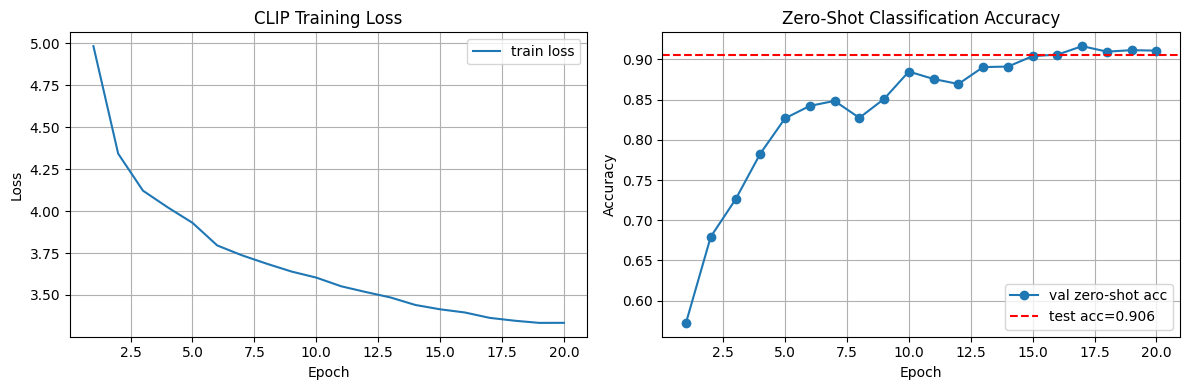

In [19]:
# ── Test-set zero-shot accuracy with best checkpoint ─────────────────────────
ckpt = torch.load(output_dir / 'best.pt', map_location=DEVICE)
vit.load_state_dict(ckpt['vit'])
proj_heads.load_state_dict(ckpt['proj_heads'])
logit_scale.data.copy_(ckpt['logit_scale'])

test_acc = zeroshot_classification_accuracy(
    vit=vit, projection_heads=proj_heads, text_encoder=text_encoder,
    val_loader=test_dl, class_prompts=class_prompts,
    class_indices=list(range(len(EUROSAT_CLASSES))), device=DEVICE,
)
print(f'Zero-shot test accuracy (best checkpoint): {test_acc:.4f}')

# ── Training-curve plot ───────────────────────────────────────────────────────
epochs_axis   = list(range(1, len(train_losses) + 1))
val_ep, val_ac = zip(*val_accuracies) if val_accuracies else ([], [])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_axis, train_losses, label='train loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('CLIP Training Loss'); ax1.legend(); ax1.grid(True)

ax2.plot(val_ep, val_ac, marker='o', label='val zero-shot acc')
ax2.axhline(test_acc, color='red', linestyle='--', label=f'test acc={test_acc:.3f}')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Zero-Shot Classification Accuracy'); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

## §3 Qualitative Analysis — CLIP Zero-Shot on EuroSAT

In [20]:
"""
Collect per-example predictions + similarity scores on the test set.
Requires vit, proj_heads, text_encoder, logit_scale, test_dl, class_prompts,
EUROSAT_CLASSES, and DEVICE to already be defined (run training cell first).
"""
import torch
import torch.nn.functional as F
import numpy as np

# ── Encode class text embeddings once ────────────────────────────────────────
vit.eval(); proj_heads.eval()

with torch.no_grad():
    text_feats = text_encoder(class_prompts).to(DEVICE)
    _, class_proj = proj_heads(
        torch.zeros(len(class_prompts), vit_cfg['d_model'], device=DEVICE),
        text_feats,
    )
    class_proj = F.normalize(class_proj, dim=-1)   # (C, d_proj)

# ── Collect raw images + predictions for the test split ─────────────────────
# Re-build the test set without the default transform so we can show raw pixels.
from datasets import load_dataset
from vlm.data import EUROSAT_CLASSES, _stratified_split_indices

full_ds  = load_dataset('blanchon/EuroSAT_RGB', split='train')
_, _, test_idx = _stratified_split_indices(full_ds['label'])
test_raw = full_ds.select(test_idx)

from torchvision import transforms
from vlm.data import IMAGENET_MEAN, IMAGENET_STD

to_tensor_norm = transforms.Compose([
    transforms.Resize((vit_cfg['img_size'], vit_cfg['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

records = []   # list of dicts: image_pil, true_label, pred_label, sims, correct, conf
with torch.no_grad():
    for ex in test_raw:
        pil_img   = ex['image'].convert('RGB')
        true_label = int(ex['label'])

        img_t  = to_tensor_norm(pil_img).unsqueeze(0).to(DEVICE)
        feats  = vit(img_t)                              # (1, d_model)
        ip, _  = proj_heads(feats, torch.zeros(1, text_encoder.embedding_dim, device=DEVICE))
        ip     = F.normalize(ip, dim=-1)                 # (1, d_proj)
        sims   = (ip @ class_proj.T).squeeze(0).cpu()   # (C,)

        pred_label = sims.argmax().item()
        records.append(dict(
            pil=pil_img,
            true=true_label,
            pred=pred_label,
            sims=sims.numpy(),
            correct=(pred_label == true_label),
            conf=float(sims[pred_label]),
        ))

print(f'Collected {len(records)} test examples.')
overall_acc = sum(r['correct'] for r in records) / len(records)
print(f'Overall zero-shot test accuracy: {overall_acc:.4f}')

Collected 1628 test examples.
Overall zero-shot test accuracy: 0.9066


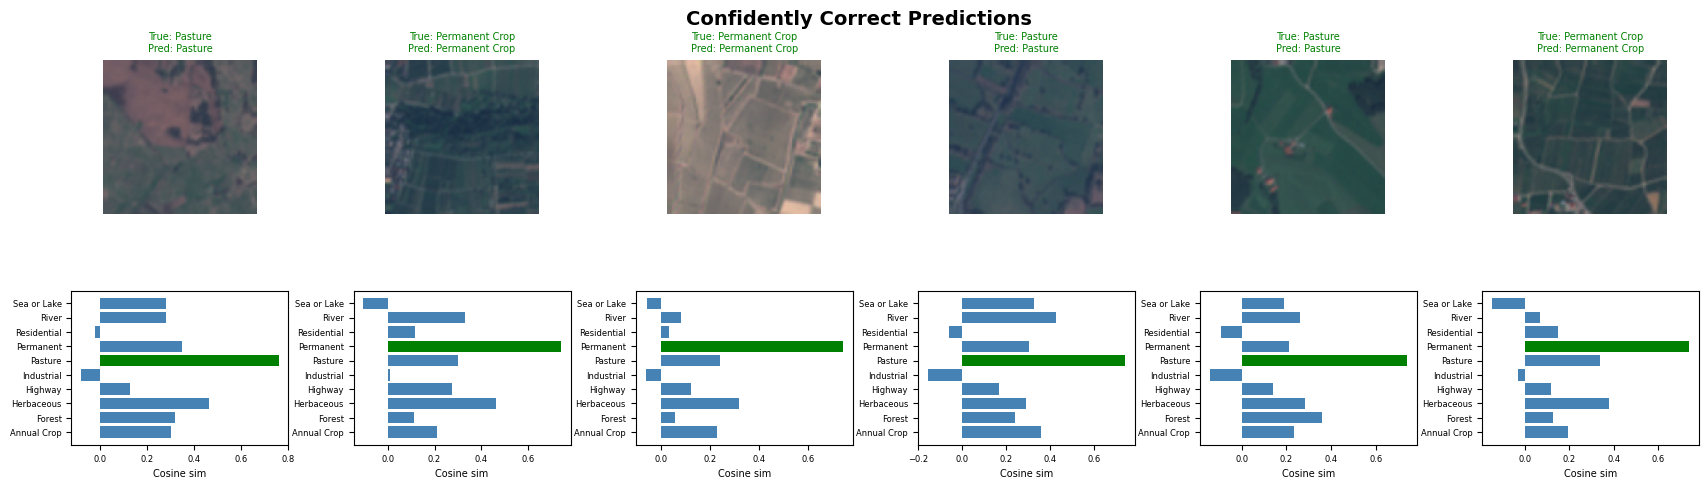

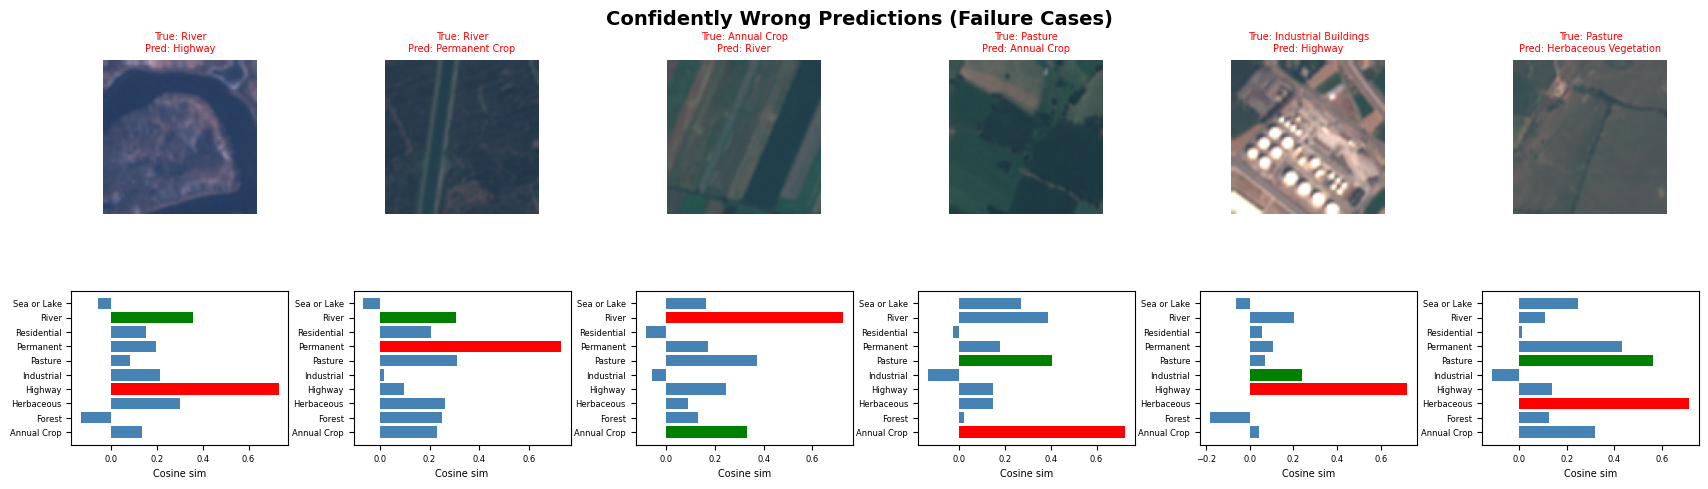

In [21]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

SHORT = [c.split()[0] if len(c) > 12 else c for c in EUROSAT_CLASSES]  # axis labels

def show_examples(recs, title, n=6):
    """Show n images with their similarity bar charts."""
    fig = plt.figure(figsize=(3.5 * n, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    gs  = gridspec.GridSpec(2, n, figure=fig, hspace=0.5, wspace=0.3)

    for col, r in enumerate(recs[:n]):
        # Image
        ax_img = fig.add_subplot(gs[0, col])
        ax_img.imshow(r['pil'].resize((96, 96)))
        ax_img.axis('off')
        color = 'green' if r['correct'] else 'red'
        ax_img.set_title(
            f"True: {EUROSAT_CLASSES[r['true']]}\nPred: {EUROSAT_CLASSES[r['pred']]}",
            fontsize=7, color=color,
        )

        # Similarity bar chart
        ax_bar = fig.add_subplot(gs[1, col])
        colors = ['steelblue'] * len(EUROSAT_CLASSES)
        colors[r['true']] = 'green'
        if not r['correct']:
            colors[r['pred']] = 'red'
        ax_bar.barh(range(len(EUROSAT_CLASSES)), r['sims'], color=colors)
        ax_bar.set_yticks(range(len(EUROSAT_CLASSES)))
        ax_bar.set_yticklabels(SHORT, fontsize=6)
        ax_bar.set_xlabel('Cosine sim', fontsize=7)
        ax_bar.tick_params(axis='x', labelsize=6)

    plt.show()

# ── (A) Most confidently correct examples ─────────────────────────────────────
correct_sorted = sorted([r for r in records if r['correct']], key=lambda r: -r['conf'])
show_examples(correct_sorted[:6], 'Confidently Correct Predictions')

# ── (B) Most confidently wrong (failure cases) ────────────────────────────────
wrong_sorted = sorted([r for r in records if not r['correct']], key=lambda r: -r['conf'])
show_examples(wrong_sorted[:6], 'Confidently Wrong Predictions (Failure Cases)')

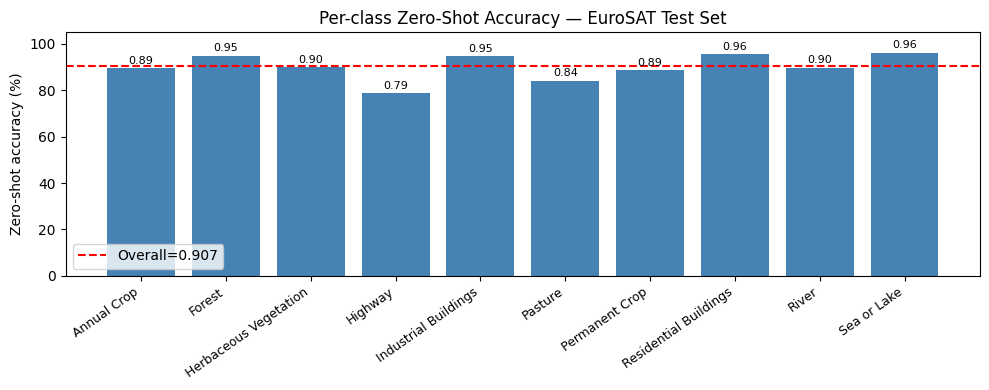

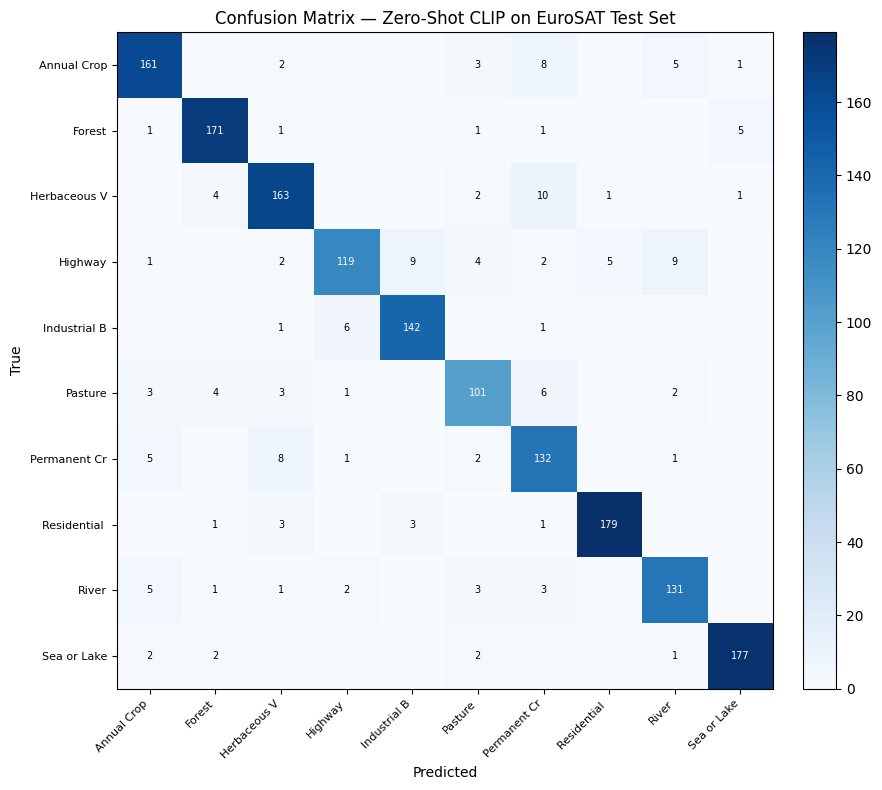

Easiest classes:
  Sea or Lake                     acc=0.962  (n=184)
  Residential Buildings           acc=0.957  (n=187)
  Forest                          acc=0.950  (n=180)
Hardest classes:
  Permanent Crop                  acc=0.886  (n=149)
  Pasture                         acc=0.842  (n=120)
  Highway                         acc=0.788  (n=151)


In [22]:
import numpy as np
import matplotlib.pyplot as plt

C = len(EUROSAT_CLASSES)

# ── (C) Per-class accuracy ─────────────────────────────────────────────────
per_class_correct = np.zeros(C)
per_class_total   = np.zeros(C)
for r in records:
    per_class_total[r['true']] += 1
    if r['correct']:
        per_class_correct[r['true']] += 1

per_class_acc = per_class_correct / np.maximum(per_class_total, 1)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(C), per_class_acc * 100, color='steelblue')
ax.set_xticks(range(C))
ax.set_xticklabels(EUROSAT_CLASSES, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Zero-shot accuracy (%)')
ax.set_title('Per-class Zero-Shot Accuracy — EuroSAT Test Set')
ax.axhline(overall_acc * 100, color='red', linestyle='--',
           label=f'Overall={overall_acc:.3f}')
ax.set_ylim(0, 105)
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{acc:.2f}', ha='center', va='bottom', fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

# ── (D) Confusion matrix ──────────────────────────────────────────────────────
conf_mat = np.zeros((C, C), dtype=int)
for r in records:
    conf_mat[r['true'], r['pred']] += 1

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(conf_mat, cmap='Blues')
ax.set_xticks(range(C)); ax.set_yticks(range(C))
ax.set_xticklabels([c[:12] for c in EUROSAT_CLASSES], rotation=45, ha='right', fontsize=8)
ax.set_yticklabels([c[:12] for c in EUROSAT_CLASSES], fontsize=8)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Zero-Shot CLIP on EuroSAT Test Set')
for i in range(C):
    for j in range(C):
        if conf_mat[i, j] > 0:
            ax.text(j, i, str(conf_mat[i, j]), ha='center', va='center',
                    fontsize=7, color='white' if conf_mat[i, j] > conf_mat.max() * 0.5 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# ── Print easy vs hard classes ────────────────────────────────────────────────
ranked = sorted(enumerate(per_class_acc), key=lambda x: -x[1])
print('Easiest classes:')
for idx, acc in ranked[:3]:
    print(f'  {EUROSAT_CLASSES[idx]:<30s}  acc={acc:.3f}  (n={int(per_class_total[idx])})')
print('Hardest classes:')
for idx, acc in ranked[-3:]:
    print(f'  {EUROSAT_CLASSES[idx]:<30s}  acc={acc:.3f}  (n={int(per_class_total[idx])})')

In [25]:
import yaml
from basics.vit import ViT
from basics.lora import apply_lora_to_attention

with open(CONFIGS['clip']) as f:
    _cfg = yaml.safe_load(f)
_v = _cfg['vit']

LORA_RANK  = 8
LORA_ALPHA = 16.0

# Build a fresh ViT and wrap it with LoRA
lora_vit = ViT(
    img_size=_v['img_size'], patch_size=_v['patch_size'],
    d_model=_v['d_model'], num_heads=_v['num_heads'],
    num_blocks=_v['num_blocks'], dropout=_v['dropout'],
)
lora_vit = apply_lora_to_attention(lora_vit, rank=LORA_RANK, alpha=LORA_ALPHA)

total_params     = sum(p.numel() for p in lora_vit.parameters())
trainable_params = sum(p.numel() for p in lora_vit.parameters() if p.requires_grad)
ratio            = trainable_params / total_params

print(f"ViT with LoRA (rank={LORA_RANK})")
print(f"  Total parameters     : {total_params:>10,}")
print(f"  Trainable parameters : {trainable_params:>10,}")
print(f"  Trainable ratio      : {ratio:.4%}")

ViT with LoRA (rank=8)
  Total parameters     : 10,995,840
  Trainable parameters :    258,048
  Trainable ratio      : 2.3468%


In [ ]:
## §4.2 — Full FT vs. LoRA vs. Linear Probe on RESISC45

In [10]:
"""
Run all three RESISC45 fine-tuning methods in sequence and collect metrics.
Requires the CLIP checkpoint at CLIP_CKPT_PATH (set below).
"""
import gc, json, math, time
from pathlib import Path

import torch
import torch.nn as nn
import yaml

from basics.vit import ViT
from basics.lora import apply_lora_to_attention
from vlm.data import build_resisc45_loaders

CLIP_CKPT_PATH = Path('runs/clip_eurosat/best.pt')   # ← adjust if stored elsewhere
assert CLIP_CKPT_PATH.exists(), f'CLIP checkpoint not found: {CLIP_CKPT_PATH}'

with open(CONFIGS['lora']) as f:
    cfg = yaml.safe_load(f)

LORA_RANK  = 8
LORA_ALPHA = 16.0
train_cfg  = cfg['train']
optim_cfg  = cfg['optim']

# ── Data (shared across all methods) ─────────────────────────────────────────
train_dl, test_dl = build_resisc45_loaders(
    img_size=64,
    batch_size=train_cfg['batch_size'],
    num_workers=train_cfg['num_workers'],
)
print(f'RESISC45  train={len(train_dl.dataset)}  test={len(test_dl.dataset)}')

clip_ckpt = torch.load(CLIP_CKPT_PATH, map_location='cpu')
vit_cfg   = clip_ckpt['cfg']['vit']


# ── Helpers ───────────────────────────────────────────────────────────────────
def make_lr_lambda(warmup_steps, total_steps):
    def f(step):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        p = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1.0 + math.cos(math.pi * p))
    return f


def build_model(method):
    vit = ViT(**vit_cfg)
    vit.load_state_dict(clip_ckpt['vit'])
    if method == 'linear_probe':
        for p in vit.parameters():
            p.requires_grad_(False)
    elif method == 'lora':
        apply_lora_to_attention(vit, rank=LORA_RANK, alpha=LORA_ALPHA)
    # full_ft: all params remain trainable
    head = nn.Linear(vit_cfg['d_model'], cfg['num_classes'])
    return vit.to(DEVICE), head.to(DEVICE)


def evaluate(vit, head):
    vit.eval(); head.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in test_dl:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            correct += (head(vit(imgs)).argmax(1) == lbls).sum().item()
            total   += lbls.size(0)
    return correct / max(total, 1)


def run_method(method):
    print(f'\n{"="*55}')
    print(f'  Method: {method}')
    print(f'{"="*55}')

    vit, head = build_model(method)

    all_params       = list(vit.parameters()) + list(head.parameters())
    trainable_params = sum(p.numel() for p in all_params if p.requires_grad)
    total_params     = sum(p.numel() for p in all_params)
    print(f'  trainable={trainable_params:,}  total={total_params:,}  '
          f'ratio={trainable_params/total_params:.4%}')

    method_lr = cfg['methods'][method].get('lr', optim_cfg['lr'])
    optimizer = torch.optim.AdamW(
        [p for p in all_params if p.requires_grad],
        lr=method_lr, weight_decay=optim_cfg['weight_decay'],
        betas=tuple(optim_cfg['betas']),
    )
    num_epochs = train_cfg['num_epochs']
    total_steps = num_epochs * len(train_dl)
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, make_lr_lambda(optim_cfg['warmup_steps'], total_steps)
    )
    criterion = nn.CrossEntropyLoss()
    log_every = train_cfg.get('log_every', 25)

    if DEVICE.type == 'cuda':
        torch.cuda.reset_peak_memory_stats(DEVICE)

    best_acc = 0.0
    t0 = time.perf_counter()

    for epoch in range(1, num_epochs + 1):
        vit.train(); head.train()
        epoch_loss = 0.0
        for step, (imgs, lbls) in enumerate(train_dl, 1):
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            loss = criterion(head(vit(imgs)), lbls)
            optimizer.zero_grad(); loss.backward()
            optimizer.step(); scheduler.step()
            epoch_loss += loss.item()
            if step % log_every == 0:
                print(f'  E{epoch} [{step}/{len(train_dl)}]  loss={loss.item():.4f}')

        acc = evaluate(vit, head)
        print(f'  Epoch {epoch}/{num_epochs}  avg_loss={epoch_loss/len(train_dl):.4f}  test_acc={acc:.4f}')
        best_acc = max(best_acc, acc)

    wall = time.perf_counter() - t0
    peak = torch.cuda.max_memory_allocated(DEVICE) / 1024**2 if DEVICE.type == 'cuda' else 0.0

    out = Path('runs') / f'resisc_{method}_rank{LORA_RANK}'
    out.mkdir(parents=True, exist_ok=True)
    metrics = dict(method=method, rank=LORA_RANK if method == 'lora' else None,
                   best_test_acc=best_acc, total_params=total_params,
                   trainable_params=trainable_params,
                   trainable_ratio=trainable_params/total_params,
                   wall_clock_s=wall, peak_mem_mb=peak)
    with open(out / 'metrics.json', 'w') as f:
        json.dump(metrics, f, indent=2)

    del vit, head, optimizer
    gc.collect(); torch.cuda.empty_cache()
    return metrics


# ── Run all three methods ─────────────────────────────────────────────────────
all_metrics = {}
for method in ['linear_probe', 'lora', 'full_ft']:
    all_metrics[method] = run_method(method)

print('\nAll runs complete.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/255M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/85.1M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/85.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/18900 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6300 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6300 [00:00<?, ? examples/s]

RESISC45  train=18900  test=6300

  Method: linear_probe
  trainable=17,325  total=10,755,117  ratio=0.1611%
  E1 [25/147]  loss=3.8227
  E1 [50/147]  loss=3.4228
  E1 [75/147]  loss=3.1032
  E1 [100/147]  loss=3.0747
  E1 [125/147]  loss=2.9371
  Epoch 1/10  avg_loss=3.2415  test_acc=0.2471
  E2 [25/147]  loss=2.6090
  E2 [50/147]  loss=2.6277
  E2 [75/147]  loss=2.5629
  E2 [100/147]  loss=2.7284
  E2 [125/147]  loss=2.5660
  Epoch 2/10  avg_loss=2.6787  test_acc=0.3013
  E3 [25/147]  loss=2.5900
  E3 [50/147]  loss=2.6488
  E3 [75/147]  loss=2.8483
  E3 [100/147]  loss=2.5453
  E3 [125/147]  loss=2.4176
  Epoch 3/10  avg_loss=2.5467  test_acc=0.3192
  E4 [25/147]  loss=2.3960
  E4 [50/147]  loss=2.3919
  E4 [75/147]  loss=2.5596
  E4 [100/147]  loss=2.2818
  E4 [125/147]  loss=2.5270
  Epoch 4/10  avg_loss=2.4657  test_acc=0.3443
  E5 [25/147]  loss=2.2379
  E5 [50/147]  loss=2.4756
  E5 [75/147]  loss=2.3171
  E5 [100/147]  loss=2.2695
  E5 [125/147]  loss=2.3695
  Epoch 5/10  avg_

Method              Test Acc    Trainable    Ratio   Time (s)  Peak Mem (MB)
---------------------------------------------------------------------------
Linear Probe          0.3737       17,325  0.1611%      100.6            204
LoRA (r=8)            0.4068      275,373  2.5004%      141.4           1108
Full FT               0.6281   10,755,117 100.0000%      111.8           1628


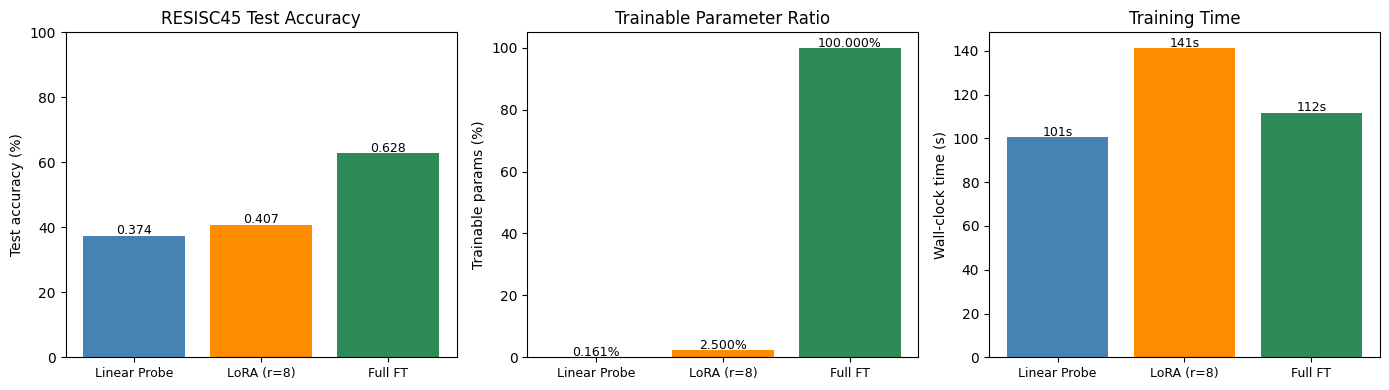

In [11]:
import matplotlib.pyplot as plt
import numpy as np

methods      = ['linear_probe', 'lora', 'full_ft']
labels       = ['Linear Probe', f'LoRA (r={LORA_RANK})', 'Full FT']
accs         = [all_metrics[m]['best_test_acc']    for m in methods]
trainable    = [all_metrics[m]['trainable_params'] for m in methods]
ratios       = [all_metrics[m]['trainable_ratio']  for m in methods]
wall_clocks  = [all_metrics[m]['wall_clock_s']     for m in methods]
peak_mems    = [all_metrics[m]['peak_mem_mb']      for m in methods]

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'{"Method":<18} {"Test Acc":>9} {"Trainable":>12} {"Ratio":>8} {"Time (s)":>10} {"Peak Mem (MB)":>14}')
print('-' * 75)
for m, lbl, acc, tr, rat, wc, pm in zip(methods, labels, accs, trainable, ratios, wall_clocks, peak_mems):
    print(f'{lbl:<18} {acc:>9.4f} {tr:>12,} {rat:>8.4%} {wc:>10.1f} {pm:>14.0f}')

# ── Bar charts ────────────────────────────────────────────────────────────────
x = np.arange(len(labels))
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(x, [a * 100 for a in accs], color=['steelblue', 'darkorange', 'seagreen'])
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_ylabel('Test accuracy (%)'); axes[0].set_title('RESISC45 Test Accuracy')
axes[0].set_ylim(0, 100)
for i, a in enumerate(accs):
    axes[0].text(i, a * 100 + 0.5, f'{a:.3f}', ha='center', fontsize=9)

axes[1].bar(x, [r * 100 for r in ratios], color=['steelblue', 'darkorange', 'seagreen'])
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, fontsize=9)
axes[1].set_ylabel('Trainable params (%)'); axes[1].set_title('Trainable Parameter Ratio')
for i, r in enumerate(ratios):
    axes[1].text(i, r * 100 + 0.1, f'{r:.3%}', ha='center', fontsize=9)

axes[2].bar(x, wall_clocks, color=['steelblue', 'darkorange', 'seagreen'])
axes[2].set_xticks(x); axes[2].set_xticklabels(labels, fontsize=9)
axes[2].set_ylabel('Wall-clock time (s)'); axes[2].set_title('Training Time')
for i, wc in enumerate(wall_clocks):
    axes[2].text(i, wc + 0.5, f'{wc:.0f}s', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## §4 — LoRA Rank Sweep

In [12]:
"""
LoRA rank sweep: train RESISC45 with LoRA at ranks r ∈ {1, 2, 4, 8, 16, 32}
and record test accuracy, trainable params, and wall-clock time.

Reuses helpers (build_model, evaluate, make_lr_lambda, train_dl, test_dl, cfg)
defined in the §4.2 cell above — run that cell first.
"""
import gc, json, math, time
from pathlib import Path

import torch
import torch.nn as nn

RANKS       = [1, 2, 4, 8, 16, 32]
ALPHA_SCALE = 2.0   # alpha = rank * ALPHA_SCALE  (keeps scaling = alpha/rank constant)
sweep_results = {}  # rank -> metrics dict

for rank in RANKS:
    alpha = rank * ALPHA_SCALE
    print(f'\n{"="*50}')
    print(f'  LoRA rank={rank}  alpha={alpha}')
    print(f'{"="*50}')

    from basics.vit import ViT
    from basics.lora import apply_lora_to_attention

    vit = ViT(**vit_cfg)
    vit.load_state_dict(clip_ckpt['vit'])
    apply_lora_to_attention(vit, rank=rank, alpha=alpha)
    head = nn.Linear(vit_cfg['d_model'], cfg['num_classes'])
    vit.to(DEVICE); head.to(DEVICE)

    all_params       = list(vit.parameters()) + list(head.parameters())
    trainable_params = sum(p.numel() for p in all_params if p.requires_grad)
    total_params     = sum(p.numel() for p in all_params)
    print(f'  trainable={trainable_params:,}  ({trainable_params/total_params:.4%})')

    method_lr = cfg['methods']['lora'].get('lr', cfg['optim']['lr'])
    optimizer = torch.optim.AdamW(
        [p for p in all_params if p.requires_grad],
        lr=method_lr,
        weight_decay=cfg['optim']['weight_decay'],
        betas=tuple(cfg['optim']['betas']),
    )
    num_epochs  = train_cfg['num_epochs']
    total_steps = num_epochs * len(train_dl)
    scheduler   = torch.optim.lr_scheduler.LambdaLR(
        optimizer, make_lr_lambda(cfg['optim']['warmup_steps'], total_steps)
    )
    criterion = nn.CrossEntropyLoss()

    if DEVICE.type == 'cuda':
        torch.cuda.reset_peak_memory_stats(DEVICE)

    best_acc = 0.0
    t0 = time.perf_counter()

    for epoch in range(1, num_epochs + 1):
        vit.train(); head.train()
        for imgs, lbls in train_dl:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            loss = criterion(head(vit(imgs)), lbls)
            optimizer.zero_grad(); loss.backward()
            optimizer.step(); scheduler.step()

        acc = evaluate(vit, head)
        best_acc = max(best_acc, acc)
        print(f'  Epoch {epoch}/{num_epochs}  test_acc={acc:.4f}')

    wall     = time.perf_counter() - t0
    peak_mem = torch.cuda.max_memory_allocated(DEVICE) / 1024**2 if DEVICE.type == 'cuda' else 0.0

    sweep_results[rank] = dict(
        rank=rank, alpha=alpha,
        best_test_acc=best_acc,
        trainable_params=trainable_params,
        total_params=total_params,
        trainable_ratio=trainable_params / total_params,
        wall_clock_s=wall,
        peak_mem_mb=peak_mem,
    )

    out = Path('runs') / f'resisc_lora_rank{rank}'
    out.mkdir(parents=True, exist_ok=True)
    with open(out / 'metrics.json', 'w') as f:
        json.dump(sweep_results[rank], f, indent=2)

    del vit, head, optimizer
    gc.collect(); torch.cuda.empty_cache()

print('\nRank sweep complete.')


  LoRA rank=1  alpha=2.0
  trainable=49,581  (0.4596%)
  Epoch 1/10  test_acc=0.1273
  Epoch 2/10  test_acc=0.2108
  Epoch 3/10  test_acc=0.2554
  Epoch 4/10  test_acc=0.2860
  Epoch 5/10  test_acc=0.3060
  Epoch 6/10  test_acc=0.3176
  Epoch 7/10  test_acc=0.3238
  Epoch 8/10  test_acc=0.3243
  Epoch 9/10  test_acc=0.3254
  Epoch 10/10  test_acc=0.3254

  LoRA rank=2  alpha=4.0
  trainable=81,837  (0.7564%)
  Epoch 1/10  test_acc=0.1367
  Epoch 2/10  test_acc=0.2278
  Epoch 3/10  test_acc=0.2783
  Epoch 4/10  test_acc=0.3073
  Epoch 5/10  test_acc=0.3219
  Epoch 6/10  test_acc=0.3390
  Epoch 7/10  test_acc=0.3457
  Epoch 8/10  test_acc=0.3511
  Epoch 9/10  test_acc=0.3517
  Epoch 10/10  test_acc=0.3514

  LoRA rank=4  alpha=8.0
  trainable=146,349  (1.3446%)
  Epoch 1/10  test_acc=0.1411
  Epoch 2/10  test_acc=0.2541
  Epoch 3/10  test_acc=0.2994
  Epoch 4/10  test_acc=0.3263
  Epoch 5/10  test_acc=0.3492
  Epoch 6/10  test_acc=0.3589
  Epoch 7/10  test_acc=0.3637
  Epoch 8/10  test_

  Rank  Test Acc    Trainable    Ratio   Time (s)
--------------------------------------------------
     1    0.3254       49,581  0.4596%      140.6
     2    0.3517       81,837  0.7564%      142.2
     4    0.3687      146,349  1.3446%      142.3
     8    0.3998      275,373  2.5004%      142.3
    16    0.4300      533,421  4.7326%      142.5
    32    0.4646    1,049,517  8.9038%      141.6


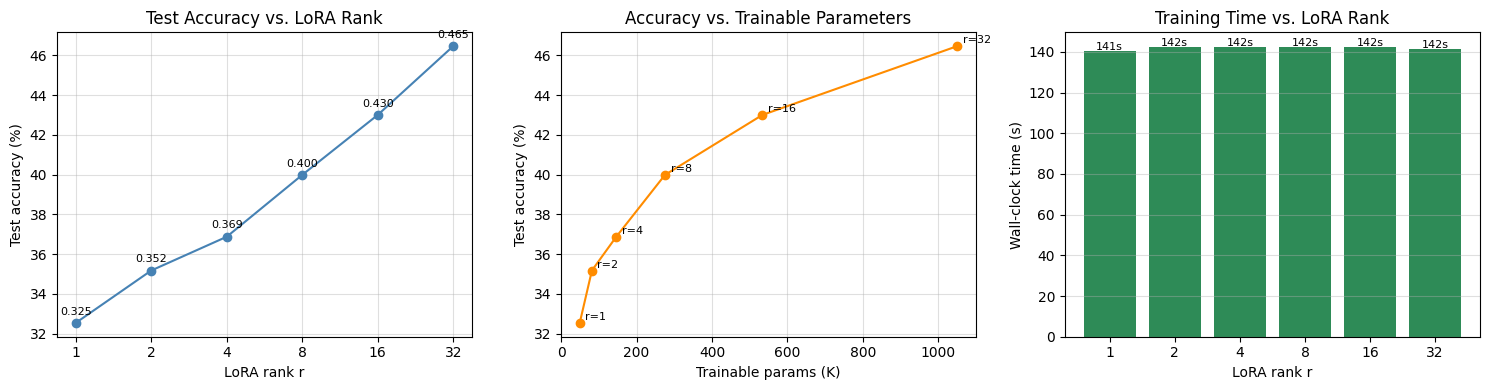


Best rank: r=32  test_acc=0.4646  trainable=1,049,517


In [13]:
import matplotlib.pyplot as plt
import numpy as np

ranks       = sorted(sweep_results.keys())
accs        = [sweep_results[r]['best_test_acc']    for r in ranks]
trainables  = [sweep_results[r]['trainable_params'] for r in ranks]
ratios      = [sweep_results[r]['trainable_ratio']  for r in ranks]
wall_clocks = [sweep_results[r]['wall_clock_s']     for r in ranks]

# ── Summary table ──────────────────────────────────────────────────────────────
print(f'{"Rank":>6} {"Test Acc":>9} {"Trainable":>12} {"Ratio":>8} {"Time (s)":>10}')
print('-' * 50)
for r, acc, tr, rat, wc in zip(ranks, accs, trainables, ratios, wall_clocks):
    print(f'{r:>6} {acc:>9.4f} {tr:>12,} {rat:>8.4%} {wc:>10.1f}')

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) Test accuracy vs rank
axes[0].plot(ranks, [a * 100 for a in accs], marker='o', color='steelblue')
axes[0].set_xscale('log', base=2)
axes[0].set_xticks(ranks); axes[0].set_xticklabels(ranks)
axes[0].set_xlabel('LoRA rank r'); axes[0].set_ylabel('Test accuracy (%)')
axes[0].set_title('Test Accuracy vs. LoRA Rank')
axes[0].grid(True, alpha=0.4)
for r, a in zip(ranks, accs):
    axes[0].annotate(f'{a:.3f}', (r, a * 100), textcoords='offset points',
                     xytext=(0, 6), ha='center', fontsize=8)

# (b) Accuracy vs trainable parameters (efficiency frontier)
axes[1].plot([t / 1e3 for t in trainables], [a * 100 for a in accs],
             marker='o', color='darkorange')
axes[1].set_xlabel('Trainable params (K)'); axes[1].set_ylabel('Test accuracy (%)')
axes[1].set_title('Accuracy vs. Trainable Parameters')
axes[1].grid(True, alpha=0.4)
for r, tr, a in zip(ranks, trainables, accs):
    axes[1].annotate(f'r={r}', (tr / 1e3, a * 100), textcoords='offset points',
                     xytext=(4, 2), fontsize=8)

# (c) Training time vs rank
axes[2].bar([str(r) for r in ranks], wall_clocks, color='seagreen')
axes[2].set_xlabel('LoRA rank r'); axes[2].set_ylabel('Wall-clock time (s)')
axes[2].set_title('Training Time vs. LoRA Rank')
axes[2].grid(True, axis='y', alpha=0.4)
for i, (r, wc) in enumerate(zip(ranks, wall_clocks)):
    axes[2].text(i, wc + 0.5, f'{wc:.0f}s', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

# ── Best rank by accuracy ──────────────────────────────────────────────────────
best_rank = max(sweep_results, key=lambda r: sweep_results[r]['best_test_acc'])
print(f'\nBest rank: r={best_rank}  '
      f'test_acc={sweep_results[best_rank]["best_test_acc"]:.4f}  '
      f'trainable={sweep_results[best_rank]["trainable_params"]:,}')

## §5.4 — VLM Token Injection

## Problem (injection compare) — Which injection strategy is best?

In [12]:
import subprocess, sys

# Install gdown if not already available
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'gdown'], check=True)

import gdown
from pathlib import Path

ARCHIVE = Path('data/clevr_mini.zip')
DEST    = Path('data/clevr_mini')

if not (DEST / 'train.jsonl').exists():
    ARCHIVE.parent.mkdir(parents=True, exist_ok=True)
    gdown.download(id='1KsswLqfYLl1d91pg5kGUgwtPslo8njTB', output=str(ARCHIVE), quiet=False)
    import zipfile
    with zipfile.ZipFile(ARCHIVE) as zf:
        zf.extractall(ARCHIVE.parent)
    print(f'Extracted to {DEST}')
else:
    print(f'CLEVR-mini already present at {DEST}')

Downloading...
From (original): https://drive.google.com/uc?id=1KsswLqfYLl1d91pg5kGUgwtPslo8njTB
From (redirected): https://drive.google.com/uc?id=1KsswLqfYLl1d91pg5kGUgwtPslo8njTB&confirm=t&uuid=f0bbe90c-905f-406a-875e-891a1998f7e4
To: /content/cs148b_hw3/data/clevr_mini.zip
100%|██████████| 1.79G/1.79G [00:20<00:00, 87.4MB/s]


Extracted to data/clevr_mini


In [18]:
"""
Train each of the three injection strategies for 2000 steps on CLEVR.
Freeze config A: ViT frozen, projector trained, decoder frozen.
Shared: batch_size=32, lr=1e-4, AdamW.
"""
import gc, itertools, json, math, time
from pathlib import Path

import torch
import torch.nn as nn
import yaml
from transformers import AutoModelForCausalLM, AutoTokenizer

from basics.vit import ViT
from vlm.data import build_clevr_loaders
from vlm.eval import batch_clevr_accuracy
from vlm.model import VisionLanguageModel
from vlm.projector import VisionLanguageProjector
from scripts.train_vlm import build_batch_tensors, make_lr_lambda

with open(CONFIGS['vlm']) as f:
    cfg = yaml.safe_load(f)

CLIP_CKPT_PATH = Path('runs/clip_eurosat/best.pt')
assert CLIP_CKPT_PATH.exists(), f'CLIP checkpoint not found: {CLIP_CKPT_PATH}'

clip_ckpt  = torch.load(CLIP_CKPT_PATH, map_location='cpu')
vit_cfg_   = clip_ckpt['cfg']['vit']
dec_cfg    = cfg['decoder']
torch_dtype = getattr(torch, dec_cfg.get('torch_dtype', 'bfloat16'))

# Compute N_vis for each injection mode once
PATCH_SIZE = vit_cfg_['patch_size']
IMG_SIZE   = vit_cfg_['img_size']
N_PATCHES  = (IMG_SIZE // PATCH_SIZE) ** 2   # e.g. (64//8)^2 = 64
N_VIS = {
    'cls':          1,
    'all_patches':  N_PATCHES + 1,   # CLS + all patches
    'interleaved':  N_PATCHES + 1,   # same tokens, placed inline
}

NUM_STEPS  = 2000
LR         = 1e-4
BATCH_SIZE = 32
EVAL_MAX   = 500
EVAL_EVERY = 500
GEN_KWARGS = dict(max_new_tokens=32, do_sample=False)

# ── Shared data loaders ───────────────────────────────────────────────────────
train_dl_inj, val_dl_inj = build_clevr_loaders(
    img_size=IMG_SIZE, batch_size=BATCH_SIZE, num_workers=4
)

injection_results = {}   # injection_mode -> metrics dict

for INJECTION in ['cls', 'all_patches', 'interleaved']:
    print(f'\n{"="*60}')
    print(f'  Injection: {INJECTION}   (N_vis={N_VIS[INJECTION]})')
    print(f'{"="*60}')

    # ── Build tokenizer (add <image> token for interleaved) ───────────────────
    tokenizer = AutoTokenizer.from_pretrained(dec_cfg['model_name'])
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    image_token    = None
    image_token_id = None
    if INJECTION == 'interleaved':
        image_token = '<image>'
        tokenizer.add_special_tokens({'additional_special_tokens': [image_token]})
        image_token_id = tokenizer.convert_tokens_to_ids(image_token)

    # ── Decoder (causal mask, flash-attn) ─────────────────────────────────────
    decoder = AutoModelForCausalLM.from_pretrained(
        dec_cfg['model_name'], torch_dtype=torch_dtype,
        attn_implementation='sdpa',
    ).to(DEVICE)
    if image_token_id is not None:
        decoder.resize_token_embeddings(len(tokenizer))

    # Freeze decoder entirely
    for p in decoder.parameters():
        p.requires_grad_(False)

    # ── ViT (frozen) ──────────────────────────────────────────────────────────
    vit = ViT(**vit_cfg_).to(DEVICE)
    vit.load_state_dict(clip_ckpt['vit'])
    for p in vit.parameters():
        p.requires_grad_(False)

    # ── Projector (trainable) ─────────────────────────────────────────────────
    projector = VisionLanguageProjector(
        d_image=vit_cfg_['d_model'],
        d_decoder=decoder.config.hidden_size,
        expansion=cfg['projector'].get('expansion', 4),
    ).to(DEVICE)

    model = VisionLanguageModel(
        vit=vit, projector=projector, decoder=decoder,
        tokenizer=tokenizer, image_token_id=image_token_id,
    )

    trainable = list(projector.parameters())
    n_train   = sum(p.numel() for p in trainable)
    print(f'  Trainable params: {n_train:,}  (projector only)')

    optimizer = torch.optim.AdamW(trainable, lr=LR, weight_decay=0.0, betas=(0.9, 0.95))
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, make_lr_lambda(warmup_steps=50, total_steps=NUM_STEPS)
    )
    criterion_used = nn.CrossEntropyLoss()

    if DEVICE.type == 'cuda':
        torch.cuda.reset_peak_memory_stats(DEVICE)

    train_iter  = itertools.cycle(train_dl_inj)
    step_times  = []
    best_val_acc = 0.0
    optimizer.zero_grad()

    for step in range(1, NUM_STEPS + 1):
        model.train()
        batch      = next(train_iter)
        images     = batch['image'].to(DEVICE)
        questions  = batch['question']
        answers    = batch['answer']

        input_ids, attention_mask, labels = build_batch_tensors(
            questions, answers, tokenizer, image_token=image_token
        )
        input_ids      = input_ids.to(DEVICE)
        attention_mask = attention_mask.to(DEVICE)
        labels         = labels.to(DEVICE)

        t0 = time.perf_counter()
        with torch.autocast(device_type=DEVICE.type, dtype=torch_dtype):
            out  = model(images, input_ids, attention_mask, labels,
                         injection=INJECTION, mask_mode='causal')
            loss = out['loss']

        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable, 1.0)
        optimizer.step(); scheduler.step(); optimizer.zero_grad()
        step_times.append(time.perf_counter() - t0)

        if step % 200 == 0:
            print(f'  Step {step}/{NUM_STEPS}  loss={loss.item():.4f}  '
                  f'ms/step={step_times[-1]*1000:.0f}')

        if step % EVAL_EVERY == 0 or step == NUM_STEPS:
            model.eval()
            preds, golds, qtypes = [], [], []
            count = 0
            for vb in val_dl_inj:
                if count >= EVAL_MAX: break
                vi = vb['image'].to(DEVICE)
                vq, va, vt = vb['question'], vb['answer'], vb['q_type']
                vp = [(f'{image_token} ' if image_token else '') +
                      f'Question: {q} Answer:' for q in vq]
                with torch.autocast(device_type=DEVICE.type, dtype=torch_dtype):
                    gen = model.generate(vi, vp, injection=INJECTION, **GEN_KWARGS)
                preds += gen; golds += va; qtypes += vt; count += len(va)
            acc_d    = batch_clevr_accuracy(preds, golds, qtypes)
            val_acc  = acc_d['overall']
            best_val_acc = max(best_val_acc, val_acc)
            print(f'  [eval step {step}] val_acc={val_acc:.4f}  ' +
                  '  '.join(f'{k}={v:.4f}' for k, v in acc_d.items() if k != 'overall'))

    peak_mem_mb   = (torch.cuda.max_memory_allocated(DEVICE) / 1024**2
                     if DEVICE.type == 'cuda' else 0.0)
    ms_per_step   = sum(step_times) / len(step_times) * 1000

    injection_results[INJECTION] = dict(
        injection=INJECTION,
        n_vis_tokens=N_VIS[INJECTION],
        best_val_acc=best_val_acc,
        peak_mem_mb=peak_mem_mb,
        ms_per_step=ms_per_step,
    )
    out_dir = Path('runs') / f'vlm_{INJECTION}_causal_A'
    out_dir.mkdir(parents=True, exist_ok=True)
    with open(out_dir / 'injection_metrics.json', 'w') as f:
        json.dump(injection_results[INJECTION], f, indent=2)
    torch.save({
        'projector': projector.state_dict(),
        'vit': vit.state_dict(),
        'decoder': decoder.state_dict(),
        'vit_cfg': vit_cfg_, 'injection': INJECTION, 'mask_mode': 'causal',
        'decoder_model_name': dec_cfg['model_name'], 'val_acc': best_val_acc,
        'torch_dtype': dec_cfg.get('torch_dtype', 'bfloat16'), 'image_token_id': image_token_id,
    }, out_dir / 'best.pt')

    del model, vit, projector, decoder, optimizer
    gc.collect(); torch.cuda.empty_cache()

print('\nAll injection strategies complete.')


  Injection: cls   (N_vis=1)


generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

  Trainable params: 2,066,880  (projector only)
  Step 200/2000  loss=0.8178  ms/step=138
  Step 400/2000  loss=0.6971  ms/step=133
  [eval step 500] val_acc=0.0200  count=0.0000  spatial=0.0385  compare_attr=0.0000  exist=0.0000  query_attr=0.0101
  Step 600/2000  loss=0.4457  ms/step=134
  Step 800/2000  loss=0.6356  ms/step=135
  Step 1000/2000  loss=0.6096  ms/step=134
  [eval step 1000] val_acc=0.0180  count=0.0000  spatial=0.0385  compare_attr=0.0000  exist=0.0000  query_attr=0.0000
  Step 1200/2000  loss=0.4183  ms/step=134
  Step 1400/2000  loss=0.6106  ms/step=135
  [eval step 1500] val_acc=0.0140  count=0.0000  spatial=0.0299  compare_attr=0.0000  exist=0.0000  query_attr=0.0000
  Step 1600/2000  loss=0.5708  ms/step=136
  Step 1800/2000  loss=0.5398  ms/step=132
  Step 2000/2000  loss=0.4642  ms/step=134
  [eval step 2000] val_acc=0.0180  count=0.0000  spatial=0.0385  compare_attr=0.0000  exist=0.0000  query_attr=0.0000

  Injection: all_patches   (N_vis=65)
  Trainable para

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


  Trainable params: 2,066,880  (projector only)
  Step 200/2000  loss=0.5883  ms/step=160
  Step 400/2000  loss=0.6010  ms/step=154
  [eval step 500] val_acc=0.0140  count=0.0000  spatial=0.0299  compare_attr=0.0000  exist=0.0000  query_attr=0.0000
  Step 600/2000  loss=0.4569  ms/step=155
  Step 800/2000  loss=0.5863  ms/step=156
  Step 1000/2000  loss=0.4336  ms/step=163
  [eval step 1000] val_acc=0.0480  count=0.0323  spatial=0.0684  compare_attr=0.0000  exist=0.0167  query_attr=0.0404
  Step 1200/2000  loss=0.4759  ms/step=165
  Step 1400/2000  loss=0.4872  ms/step=153
  [eval step 1500] val_acc=0.0320  count=0.0215  spatial=0.0598  compare_attr=0.0000  exist=0.0000  query_attr=0.0000
  Step 1600/2000  loss=0.4736  ms/step=157
  Step 1800/2000  loss=0.4148  ms/step=153
  Step 2000/2000  loss=0.4385  ms/step=155
  [eval step 2000] val_acc=0.0280  count=0.0000  spatial=0.0556  compare_attr=0.0000  exist=0.0167  query_attr=0.0000

All injection strategies complete.


Strategy                 Val Acc  Vis Tokens  Peak Mem (MB)   ms/step
----------------------------------------------------------------------
CLS only                  0.0200           1           3588     135.8
All patches (CLS+N)       0.0240          65           6903     137.5
Interleaved               0.0480          65           6859     155.8


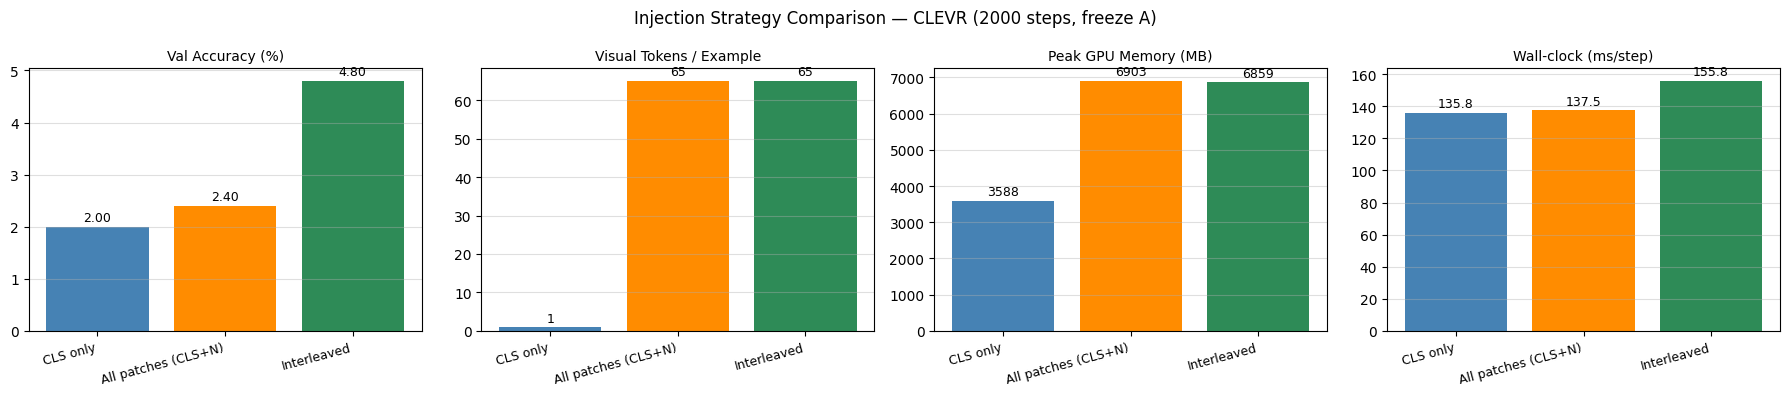


Relative to CLS baseline:
  CLS only                memory 1.00×   time 1.00×
  All patches (CLS+N)     memory 1.92×   time 1.01×
  Interleaved             memory 1.91×   time 1.15×


In [19]:
import matplotlib.pyplot as plt
import numpy as np

rows    = ['cls', 'all_patches', 'interleaved']
labels  = ['CLS only', 'All patches (CLS+N)', 'Interleaved']
accs    = [injection_results[r]['best_val_acc']  for r in rows]
n_vis   = [injection_results[r]['n_vis_tokens']  for r in rows]
mem_mbs = [injection_results[r]['peak_mem_mb']   for r in rows]
ms_step = [injection_results[r]['ms_per_step']   for r in rows]

# ── Table ─────────────────────────────────────────────────────────────────────
print(f'{"Strategy":<22} {"Val Acc":>9} {"Vis Tokens":>11} {"Peak Mem (MB)":>14} {"ms/step":>9}')
print('-' * 70)
for lbl, acc, nv, mem, ms in zip(labels, accs, n_vis, mem_mbs, ms_step):
    print(f'{lbl:<22} {acc:>9.4f} {nv:>11} {mem:>14.0f} {ms:>9.1f}')

# ── Bar charts ────────────────────────────────────────────────────────────────
x      = np.arange(len(labels))
colors = ['steelblue', 'darkorange', 'seagreen']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Injection Strategy Comparison — CLEVR (2000 steps, freeze A)', fontsize=12)

for ax, vals, title, fmt in zip(
    axes,
    [[a*100 for a in accs], n_vis, mem_mbs, ms_step],
    ['Val Accuracy (%)', 'Visual Tokens / Example', 'Peak GPU Memory (MB)', 'Wall-clock (ms/step)'],
    ['.2f', 'd', '.0f', '.1f'],
):
    bars = ax.bar(x, vals, color=colors)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=9)
    ax.set_title(title, fontsize=10); ax.grid(axis='y', alpha=0.4)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{v:{fmt}}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ── Per-step memory & time growth relative to CLS ────────────────────────────
print(f'\nRelative to CLS baseline:')
for lbl, mem, ms in zip(labels, mem_mbs, ms_step):
    print(f'  {lbl:<22}  memory {mem/mem_mbs[0]:.2f}×   time {ms/ms_step[0]:.2f}×')

In [ ]:
## Problem (masking) — Image-block Bidirectional Attention vs. Causal

In [20]:
"""
Problem (masking): compare causal vs image_bidir attention masking.

Both runs use:
  injection = all_patches  (N_vis = 65 tokens)
  freeze    = A            (projector only)
  2000 steps, batch_size=32, lr=1e-4

Key difference:
  causal      — visual tokens attend causally (each patch only sees prior patches)
  image_bidir — visual tokens attend to ALL other visual tokens (bidirectional),
                text tokens attend causally to all visual tokens + prior text

Note: image_bidir requires attn_implementation='eager' so the custom 4D
      additive mask is passed through unchanged.
"""
import gc, itertools, json, math, time
from pathlib import Path

import torch
import torch.nn as nn
import yaml
from transformers import AutoModelForCausalLM, AutoTokenizer

from basics.vit import ViT
from vlm.data import build_clevr_loaders
from vlm.eval import batch_clevr_accuracy
from vlm.model import VisionLanguageModel
from vlm.projector import VisionLanguageProjector
from scripts.train_vlm import build_batch_tensors, make_lr_lambda

with open(CONFIGS['vlm']) as f:
    cfg = yaml.safe_load(f)

CLIP_CKPT_PATH = Path('runs/clip_eurosat/best.pt')
assert CLIP_CKPT_PATH.exists(), f'CLIP checkpoint not found: {CLIP_CKPT_PATH}'

clip_ckpt   = torch.load(CLIP_CKPT_PATH, map_location='cpu')
vit_cfg_    = clip_ckpt['cfg']['vit']
dec_cfg     = cfg['decoder']
torch_dtype = getattr(torch, dec_cfg.get('torch_dtype', 'bfloat16'))
dec_name    = dec_cfg['model_name']

INJECTION  = 'all_patches'
NUM_STEPS  = 500
LR         = 1e-4
BATCH_SIZE = 32
EVAL_MAX   = 100
EVAL_EVERY = 100

train_dl_m, val_dl_m = build_clevr_loaders(
    img_size=vit_cfg_['img_size'], batch_size=BATCH_SIZE, num_workers=4
)

masking_results = {}

for MASK_MODE in ['causal', 'image_bidir']:
    print(f'\n{"="*55}')
    print(f'  mask_mode = {MASK_MODE}')
    print(f'{"="*55}')

    # image_bidir needs eager attention so our 4D additive mask is used as-is.
    attn_impl = 'eager' if MASK_MODE == 'image_bidir' else 'sdpa'

    # ── Models ────────────────────────────────────────────────────────────────
    tokenizer = AutoTokenizer.from_pretrained(dec_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    decoder = AutoModelForCausalLM.from_pretrained(
        dec_name, torch_dtype=torch_dtype, attn_implementation=attn_impl,
    ).to(DEVICE)
    for p in decoder.parameters():
        p.requires_grad_(False)

    vit = ViT(**vit_cfg_).to(DEVICE)
    vit.load_state_dict(clip_ckpt['vit'])
    for p in vit.parameters():
        p.requires_grad_(False)

    projector = VisionLanguageProjector(
        d_image=vit_cfg_['d_model'],
        d_decoder=decoder.config.hidden_size,
        expansion=cfg['projector'].get('expansion', 4),
    ).to(DEVICE)

    model = VisionLanguageModel(
        vit=vit, projector=projector, decoder=decoder,
        tokenizer=tokenizer, image_token_id=None,
    )

    trainable = list(projector.parameters())
    optimizer = torch.optim.AdamW(trainable, lr=LR, weight_decay=0.0, betas=(0.9, 0.95))
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, make_lr_lambda(warmup_steps=50, total_steps=NUM_STEPS)
    )

    if DEVICE.type == 'cuda':
        torch.cuda.reset_peak_memory_stats(DEVICE)

    train_iter   = itertools.cycle(train_dl_m)
    step_times   = []
    best_val_acc = 0.0
    train_losses = []
    optimizer.zero_grad()

    for step in range(1, NUM_STEPS + 1):
        model.train()
        batch      = next(train_iter)
        images     = batch['image'].to(DEVICE)
        questions  = batch['question']
        answers    = batch['answer']

        input_ids, attention_mask, labels = build_batch_tensors(
            questions, answers, tokenizer
        )
        input_ids      = input_ids.to(DEVICE)
        attention_mask = attention_mask.to(DEVICE)
        labels         = labels.to(DEVICE)

        t0 = time.perf_counter()
        with torch.autocast(device_type=DEVICE.type, dtype=torch_dtype):
            out  = model(images, input_ids, attention_mask, labels,
                         injection=INJECTION, mask_mode=MASK_MODE)
            loss = out['loss']

        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable, 1.0)
        optimizer.step(); scheduler.step(); optimizer.zero_grad()
        step_times.append(time.perf_counter() - t0)
        train_losses.append(loss.item())

        if step % 200 == 0:
            print(f'  Step {step}/{NUM_STEPS}  loss={loss.item():.4f}  '
                  f'ms/step={step_times[-1]*1000:.0f}')

        if step % EVAL_EVERY == 0 or step == NUM_STEPS:
            model.eval()
            preds, golds, qtypes = [], [], []
            count = 0
            for vb in val_dl_m:
                if count >= EVAL_MAX: break
                vi = vb['image'].to(DEVICE)
                vq, va, vt = vb['question'], vb['answer'], vb['q_type']
                vp = [f'Question: {q} Answer:' for q in vq]
                with torch.autocast(device_type=DEVICE.type, dtype=torch_dtype):
                    gen = model.generate(vi, vp, injection=INJECTION,
                                         max_new_tokens=32, do_sample=False)
                preds += gen; golds += va; qtypes += vt; count += len(va)
            acc_d    = batch_clevr_accuracy(preds, golds, qtypes)
            val_acc  = acc_d['overall']
            best_val_acc = max(best_val_acc, val_acc)
            print(f'  [step {step}] val_acc={val_acc:.4f}  ' +
                  '  '.join(f'{k}={v:.4f}' for k, v in acc_d.items() if k != 'overall'))

    peak_mem = torch.cuda.max_memory_allocated(DEVICE) / 1024**2 if DEVICE.type == 'cuda' else 0.0
    ms_step  = sum(step_times) / len(step_times) * 1000

    masking_results[MASK_MODE] = dict(
        mask_mode=MASK_MODE,
        best_val_acc=best_val_acc,
        peak_mem_mb=peak_mem,
        ms_per_step=ms_step,
        train_losses=train_losses,
    )
    out_dir = Path('runs') / f'vlm_{INJECTION}_{MASK_MODE}_A'
    out_dir.mkdir(parents=True, exist_ok=True)
    with open(out_dir / 'masking_metrics.json', 'w') as f:
        json.dump({k: v for k, v in masking_results[MASK_MODE].items()
                   if k != 'train_losses'}, f, indent=2)
    torch.save({
        'projector': projector.state_dict(),
        'vit': vit.state_dict(),
        'decoder': decoder.state_dict(),
        'vit_cfg': vit_cfg_, 'mask_mode': MASK_MODE, 'injection': INJECTION,
        'decoder_model_name': dec_name, 'val_acc': best_val_acc,
        'torch_dtype': dec_cfg.get('torch_dtype', 'bfloat16'),
    }, out_dir / 'best.pt')

    del model, vit, projector, decoder, optimizer
    gc.collect(); torch.cuda.empty_cache()

print('\nMasking comparison complete.')


  mask_mode = causal
  Step 200/2000  loss=0.7001  ms/step=143
  Step 400/2000  loss=0.5250  ms/step=143
  [step 500] val_acc=0.0160  count=0.0000  spatial=0.0342  compare_attr=0.0000  exist=0.0000  query_attr=0.0000
  Step 600/2000  loss=0.6107  ms/step=142
  Step 800/2000  loss=0.5022  ms/step=144
  Step 1000/2000  loss=0.5148  ms/step=141
  [step 1000] val_acc=0.0160  count=0.0000  spatial=0.0342  compare_attr=0.0000  exist=0.0000  query_attr=0.0000
  Step 1200/2000  loss=0.4372  ms/step=143
  Step 1400/2000  loss=0.3639  ms/step=142
  [step 1500] val_acc=0.0140  count=0.0000  spatial=0.0299  compare_attr=0.0000  exist=0.0000  query_attr=0.0000
  Step 1600/2000  loss=0.4623  ms/step=141
  Step 1800/2000  loss=0.3986  ms/step=139
  Step 2000/2000  loss=0.4066  ms/step=140
  [step 2000] val_acc=0.0140  count=0.0000  spatial=0.0299  compare_attr=0.0000  exist=0.0000  query_attr=0.0000

  mask_mode = image_bidir
  Step 200/2000  loss=1.0232  ms/step=157
  Step 400/2000  loss=0.6643  ms

Mask mode                Val Acc  Peak Mem (MB)   ms/step
----------------------------------------------------------
Causal (baseline)         0.0160           6863     142.0
Image-bidir               0.0140           7772     152.9

Δ accuracy (bidir − causal): -0.0020 (regression)


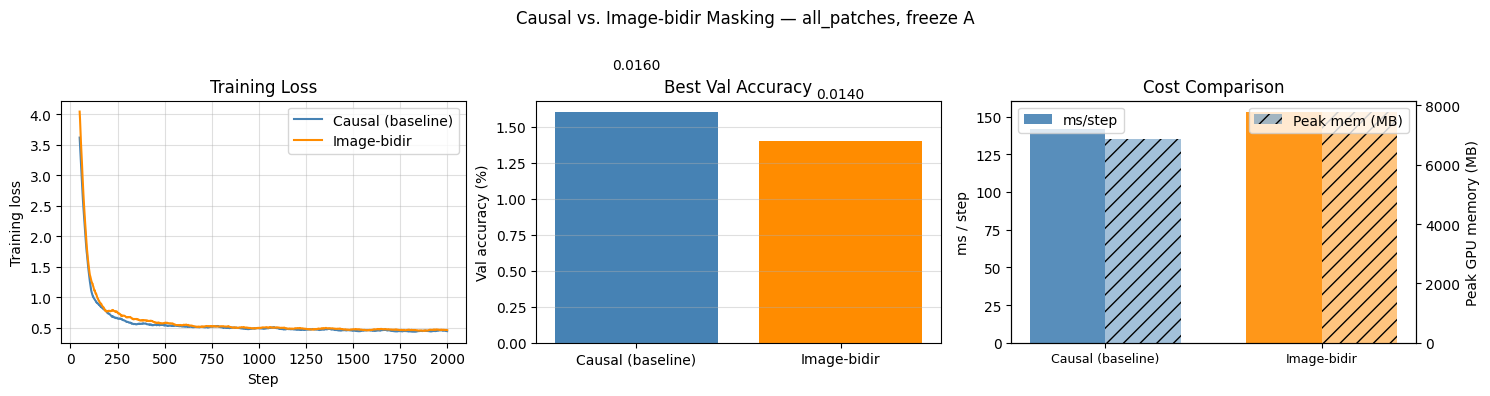

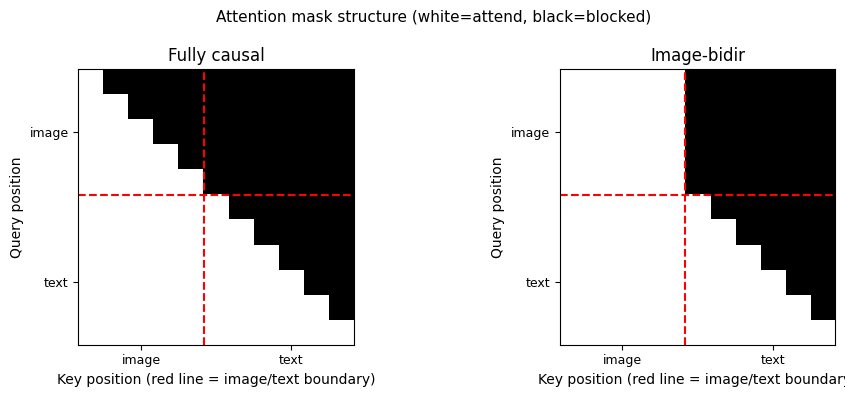

In [21]:
import json, matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Load from memory or disk
try:
    _ = masking_results
except NameError:
    masking_results = {}

for mode in ['causal', 'image_bidir']:
    if mode not in masking_results:
        p = Path('runs') / f'vlm_all_patches_{mode}_A' / 'masking_metrics.json'
        assert p.exists(), f'No results for {mode} — run the training cell first.'
        with open(p) as f:
            masking_results[mode] = json.load(f)

modes  = ['causal', 'image_bidir']
labels = ['Causal (baseline)', 'Image-bidir']
accs   = [masking_results[m]['best_val_acc'] for m in modes]
mems   = [masking_results[m]['peak_mem_mb']  for m in modes]
mss    = [masking_results[m]['ms_per_step']  for m in modes]

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'{"Mask mode":<22} {"Val Acc":>9} {"Peak Mem (MB)":>14} {"ms/step":>9}')
print('-' * 58)
for lbl, acc, mem, ms in zip(labels, accs, mems, mss):
    print(f'{lbl:<22} {acc:>9.4f} {mem:>14.0f} {ms:>9.1f}')
delta = accs[1] - accs[0]
print(f'\nΔ accuracy (bidir − causal): {delta:+.4f} '
      f'({"improvement" if delta > 0 else "regression"})')

# ── Training-loss curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Causal vs. Image-bidir Masking — all_patches, freeze A', fontsize=12)
colors = {'causal': 'steelblue', 'image_bidir': 'darkorange'}

# (a) Training loss curves
ax = axes[0]
for m, lbl in zip(modes, labels):
    losses = masking_results[m].get('train_losses', [])
    if losses:
        # smooth with a 50-step window
        w = 50
        smoothed = np.convolve(losses, np.ones(w)/w, mode='valid')
        ax.plot(range(w-1, len(losses)), smoothed, label=lbl, color=colors[m])
ax.set_xlabel('Step'); ax.set_ylabel('Training loss')
ax.set_title('Training Loss'); ax.legend(); ax.grid(True, alpha=0.4)

# (b) Final val accuracy bar
ax = axes[1]
bars = ax.bar(labels, [a*100 for a in accs], color=[colors[m] for m in modes])
ax.set_ylabel('Val accuracy (%)'); ax.set_title('Best Val Accuracy')
ax.grid(axis='y', alpha=0.4)
for bar, a in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{a:.4f}', ha='center', fontsize=10)

# (c) ms/step and memory side-by-side
ax = axes[2]
x = np.arange(2)
w = 0.35
b1 = ax.bar(x - w/2, mss,  w, label='ms/step',        color=[colors[m] for m in modes], alpha=0.9)
ax2 = ax.twinx()
b2 = ax2.bar(x + w/2, mems, w, label='Peak mem (MB)', color=[colors[m] for m in modes], alpha=0.5, hatch='//')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('ms / step'); ax2.set_ylabel('Peak GPU memory (MB)')
ax.set_title('Cost Comparison')
ax.legend(loc='upper left'); ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# ── Mask visualisation ────────────────────────────────────────────────────────
import torch
from vlm.masking import build_causal_mask, build_image_bidir_mask

N_VIS = 5; N_TXT = 6   # small example for illustration

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Attention mask structure (white=attend, black=blocked)', fontsize=11)

for ax, (title, mask) in zip(axes, [
    ('Fully causal', build_causal_mask(N_VIS+N_TXT, 'cpu', torch.float32)),
    ('Image-bidir',  build_image_bidir_mask(N_VIS, N_TXT, 'cpu', torch.float32)),
]):
    m = mask.squeeze().numpy()
    m_vis = (m == 0).astype(float)   # 0=attend → white
    ax.imshow(m_vis, cmap='gray', vmin=0, vmax=1, aspect='equal')
    ax.axvline(N_VIS - 0.5, color='red', linewidth=1.5, linestyle='--')
    ax.axhline(N_VIS - 0.5, color='red', linewidth=1.5, linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Key position (red line = image/text boundary)')
    ax.set_ylabel('Query position')
    ax.set_xticks([N_VIS//2, N_VIS + N_TXT//2])
    ax.set_xticklabels(['image', 'text'], fontsize=9)
    ax.set_yticks([N_VIS//2, N_VIS + N_TXT//2])
    ax.set_yticklabels(['image', 'text'], fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
## Problem (freezing) — What to Train, and When

In [25]:
"""
Problem (freezing): compare all four freeze configs on CLEVR.

Config  | ViT       | Projector | Decoder
--------|-----------|-----------|------------------
A       | frozen    | trained   | frozen
B       | frozen    | trained   | LoRA (r=8)
C       | frozen    | trained   | full FT
D       | trained   | trained   | full FT

All runs: injection=all_patches, mask_mode=causal, 2000 steps,
          batch_size=32, lr=1e-4, AdamW.
"""
import gc, itertools, json, math, time
from pathlib import Path

import torch
import torch.nn as nn
import yaml
from transformers import AutoModelForCausalLM, AutoTokenizer

from basics.vit import ViT
from vlm.data import build_clevr_loaders
from vlm.eval import batch_clevr_accuracy
from vlm.model import VisionLanguageModel
from vlm.projector import VisionLanguageProjector
from scripts.train_vlm import apply_freeze_config, build_batch_tensors, make_lr_lambda

with open(CONFIGS['vlm']) as f:
    cfg = yaml.safe_load(f)

CLIP_CKPT_PATH = Path('runs/clip_eurosat/best.pt')
assert CLIP_CKPT_PATH.exists(), f'CLIP checkpoint not found: {CLIP_CKPT_PATH}'

clip_ckpt   = torch.load(CLIP_CKPT_PATH, map_location='cpu')
vit_cfg_    = clip_ckpt['cfg']['vit']
dec_cfg     = cfg['decoder']
torch_dtype = getattr(torch, dec_cfg.get('torch_dtype', 'bfloat16'))
dec_name    = dec_cfg['model_name']

INJECTION  = 'all_patches'
MASK_MODE  = 'causal'
NUM_STEPS  = 2000
LR         = 1e-4
BATCH_SIZE = 32
EVAL_MAX   = 500
EVAL_EVERY = 500
LORA_RANK  = 8
LORA_ALPHA = 16.0

FREEZE_DESCRIPTIONS = {
    'A': 'Projector only',
    'B': 'Projector + Decoder LoRA',
    'C': 'Projector + Full decoder',
    'D': 'All (ViT + Proj + Dec)',
}

train_dl_f, val_dl_f = build_clevr_loaders(
    img_size=vit_cfg_['img_size'], batch_size=BATCH_SIZE, num_workers=4
)

freezing_results = {}   # config -> metrics dict

for FC in ['A', 'B', 'C', 'D']:
    print(f'\n{"="*58}')
    print(f'  Freeze config {FC}: {FREEZE_DESCRIPTIONS[FC]}')
    print(f'{"="*58}')

    # ── Build fresh models for every run ─────────────────────────────────────
    tokenizer = AutoTokenizer.from_pretrained(dec_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    decoder = AutoModelForCausalLM.from_pretrained(
        dec_name, torch_dtype=torch_dtype, attn_implementation='sdpa',
    ).to(DEVICE)

    vit = ViT(**vit_cfg_).to(DEVICE)
    vit.load_state_dict(clip_ckpt['vit'])

    projector = VisionLanguageProjector(
        d_image=vit_cfg_['d_model'],
        d_decoder=decoder.config.hidden_size,
        expansion=cfg['projector'].get('expansion', 4),
    ).to(DEVICE)

    model = VisionLanguageModel(
        vit=vit, projector=projector, decoder=decoder,
        tokenizer=tokenizer, image_token_id=None,
    )

    # ── Apply freeze config ───────────────────────────────────────────────────
    apply_freeze_config(vit, projector, decoder, FC,
                        lora_rank=LORA_RANK, lora_alpha=LORA_ALPHA)

    all_params       = list(model.parameters())
    trainable_params = [p for p in all_params if p.requires_grad]
    n_trainable      = sum(p.numel() for p in trainable_params)
    n_total          = sum(p.numel() for p in all_params)
    print(f'  trainable={n_trainable:,}  total={n_total:,}  ({n_trainable/n_total:.4%})')

    # ── Optimizer ─────────────────────────────────────────────────────────────
    optimizer = torch.optim.AdamW(
        trainable_params, lr=LR, weight_decay=0.0, betas=(0.9, 0.95)
    )
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, make_lr_lambda(warmup_steps=50, total_steps=NUM_STEPS)
    )

    if DEVICE.type == 'cuda':
        torch.cuda.reset_peak_memory_stats(DEVICE)

    train_iter   = itertools.cycle(train_dl_f)
    step_times   = []
    train_losses = []
    best_val_acc = 0.0
    optimizer.zero_grad()

    for step in range(1, NUM_STEPS + 1):
        model.train()
        batch      = next(train_iter)
        images     = batch['image'].to(DEVICE)
        questions  = batch['question']
        answers    = batch['answer']

        input_ids, attn_mask, labels = build_batch_tensors(
            questions, answers, tokenizer
        )
        input_ids = input_ids.to(DEVICE)
        attn_mask = attn_mask.to(DEVICE)
        labels    = labels.to(DEVICE)

        t0 = time.perf_counter()
        with torch.autocast(device_type=DEVICE.type, dtype=torch_dtype):
            out  = model(images, input_ids, attn_mask, labels,
                         injection=INJECTION, mask_mode=MASK_MODE)
            loss = out['loss']

        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
        optimizer.step(); scheduler.step(); optimizer.zero_grad()
        step_times.append(time.perf_counter() - t0)
        train_losses.append(loss.item())

        if step % 200 == 0:
            print(f'  Step {step}/{NUM_STEPS}  loss={loss.item():.4f}  '
                  f'ms/step={step_times[-1]*1000:.0f}')

        if step % EVAL_EVERY == 0 or step == NUM_STEPS:
            model.eval()
            preds, golds, qtypes = [], [], []
            count = 0
            for vb in val_dl_f:
                if count >= EVAL_MAX: break
                vi = vb['image'].to(DEVICE)
                vq, va, vt = vb['question'], vb['answer'], vb['q_type']
                vp = [f'Question: {q} Answer:' for q in vq]
                with torch.autocast(device_type=DEVICE.type, dtype=torch_dtype):
                    gen = model.generate(vi, vp, injection=INJECTION,
                                         max_new_tokens=32, do_sample=False)
                preds += gen; golds += va; qtypes += vt; count += len(va)
            acc_d    = batch_clevr_accuracy(preds, golds, qtypes)
            val_acc  = acc_d['overall']
            best_val_acc = max(best_val_acc, val_acc)
            print(f'  [step {step}] val_acc={val_acc:.4f}  ' +
                  '  '.join(f'{k}={v:.4f}' for k, v in acc_d.items() if k != 'overall'))

    peak_mem = torch.cuda.max_memory_allocated(DEVICE) / 1024**2 if DEVICE.type == 'cuda' else 0.0
    ms_step  = sum(step_times) / len(step_times) * 1000

    freezing_results[FC] = dict(
        freeze_config=FC,
        description=FREEZE_DESCRIPTIONS[FC],
        best_val_acc=best_val_acc,
        trainable_params=n_trainable,
        total_params=n_total,
        trainable_ratio=n_trainable / n_total,
        peak_mem_mb=peak_mem,
        ms_per_step=ms_step,
        train_losses=train_losses,
    )

    out_dir = Path('runs') / f'vlm_{INJECTION}_{MASK_MODE}_{FC}'
    out_dir.mkdir(parents=True, exist_ok=True)
    with open(out_dir / 'freezing_metrics.json', 'w') as f:
        json.dump({k: v for k, v in freezing_results[FC].items()
                   if k != 'train_losses'}, f, indent=2)

    del model, vit, projector, decoder, optimizer
    gc.collect(); torch.cuda.empty_cache()

print('\nFreezing comparison complete.')


  Freeze config A: Projector only
  trainable=2,066,880  total=374,625,792  (0.5517%)
  Step 200/2000  loss=0.9560  ms/step=149
  Step 400/2000  loss=0.7216  ms/step=144
  [step 500] val_acc=0.0100  count=0.0000  spatial=0.0214  compare_attr=0.0000  exist=0.0000  query_attr=0.0000
  Step 600/2000  loss=0.5516  ms/step=142
  Step 800/2000  loss=0.5350  ms/step=144
  Step 1000/2000  loss=0.4548  ms/step=145
  [step 1000] val_acc=0.0120  count=0.0000  spatial=0.0256  compare_attr=0.0000  exist=0.0000  query_attr=0.0000
  Step 1200/2000  loss=0.4210  ms/step=142
  Step 1400/2000  loss=0.4481  ms/step=142
  [step 1500] val_acc=0.0140  count=0.0000  spatial=0.0299  compare_attr=0.0000  exist=0.0000  query_attr=0.0000
  Step 1600/2000  loss=0.4200  ms/step=142
  Step 1800/2000  loss=0.4843  ms/step=140
  Step 2000/2000  loss=0.4569  ms/step=141
  [step 2000] val_acc=0.0180  count=0.0000  spatial=0.0385  compare_attr=0.0000  exist=0.0000  query_attr=0.0000

  Freeze config B: Projector + Deco

Config                   Val Acc    Trainable    Ratio   Mem(MB)   ms/step
---------------------------------------------------------------------------
Projector only            0.0180    2,066,880  0.5517%      7696     143.5
Proj + Dec LoRA           0.0200    2,886,080  0.7687%      7887     177.5
Proj + Full Dec           0.1500  363,888,000 97.1337%     10493     170.4
All (ViT+Proj+Dec)        0.0320  374,625,792 100.0000%     11003     223.2


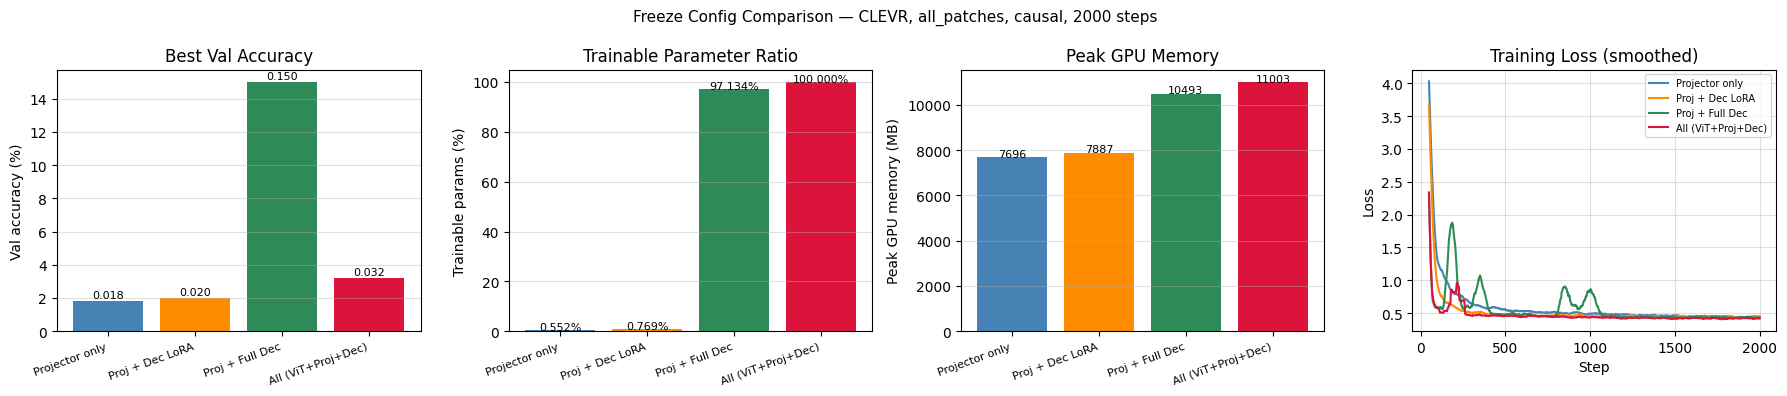

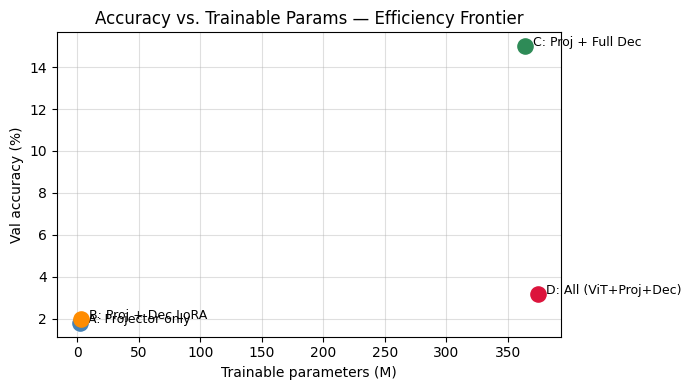

In [26]:
import json, matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Load from memory or disk
try:
    _ = freezing_results
except NameError:
    freezing_results = {}

FREEZE_DESCRIPTIONS = {
    'A': 'Projector only',
    'B': 'Proj + Dec LoRA',
    'C': 'Proj + Full Dec',
    'D': 'All (ViT+Proj+Dec)',
}
for fc in ['A', 'B', 'C', 'D']:
    if fc not in freezing_results:
        p = Path('runs') / f'vlm_all_patches_causal_{fc}' / 'freezing_metrics.json'
        assert p.exists(), f'No results for config {fc} — run the training cell first.'
        with open(p) as f:
            freezing_results[fc] = json.load(f)

configs   = ['A', 'B', 'C', 'D']
lbls      = [FREEZE_DESCRIPTIONS[c] for c in configs]
accs      = [freezing_results[c]['best_val_acc']     for c in configs]
n_trains  = [freezing_results[c]['trainable_params'] for c in configs]
ratios    = [freezing_results[c]['trainable_ratio']  for c in configs]
mems      = [freezing_results[c]['peak_mem_mb']      for c in configs]
mss       = [freezing_results[c]['ms_per_step']      for c in configs]

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'{"Config":<22} {"Val Acc":>9} {"Trainable":>12} {"Ratio":>8} {"Mem(MB)":>9} {"ms/step":>9}')
print('-' * 75)
for lbl, acc, nt, rat, mem, ms in zip(lbls, accs, n_trains, ratios, mems, mss):
    print(f'{lbl:<22} {acc:>9.4f} {nt:>12,} {rat:>8.4%} {mem:>9.0f} {ms:>9.1f}')

# ── Plots ─────────────────────────────────────────────────────────────────────
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']
x = np.arange(len(configs))
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Freeze Config Comparison — CLEVR, all_patches, causal, 2000 steps', fontsize=11)

# (a) Val accuracy
ax = axes[0]
bars = ax.bar(x, [a*100 for a in accs], color=colors)
ax.set_xticks(x); ax.set_xticklabels(lbls, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Val accuracy (%)'); ax.set_title('Best Val Accuracy')
ax.grid(axis='y', alpha=0.4)
for bar, a in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{a:.3f}', ha='center', fontsize=8)

# (b) Trainable parameter ratio
ax = axes[1]
bars = ax.bar(x, [r*100 for r in ratios], color=colors)
ax.set_xticks(x); ax.set_xticklabels(lbls, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Trainable params (%)'); ax.set_title('Trainable Parameter Ratio')
ax.grid(axis='y', alpha=0.4)
for bar, r in zip(bars, ratios):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{r:.3%}', ha='center', fontsize=8)

# (c) Peak GPU memory
ax = axes[2]
bars = ax.bar(x, mems, color=colors)
ax.set_xticks(x); ax.set_xticklabels(lbls, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Peak GPU memory (MB)'); ax.set_title('Peak GPU Memory')
ax.grid(axis='y', alpha=0.4)
for bar, m in zip(bars, mems):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            f'{m:.0f}', ha='center', fontsize=8)

# (d) Training loss curves
ax = axes[3]
w = 50
for c, lbl, col in zip(configs, lbls, colors):
    losses = freezing_results[c].get('train_losses', [])
    if losses:
        smoothed = np.convolve(losses, np.ones(w)/w, mode='valid')
        ax.plot(range(w-1, len(losses)), smoothed, label=lbl, color=col)
ax.set_xlabel('Step'); ax.set_ylabel('Loss')
ax.set_title('Training Loss (smoothed)'); ax.legend(fontsize=7); ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# ── Accuracy vs trainable params (efficiency frontier) ───────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
for c, lbl, col, nt, acc in zip(configs, lbls, colors, n_trains, accs):
    ax.scatter(nt/1e6, acc*100, color=col, s=120, zorder=5)
    ax.annotate(f'  {c}: {lbl}', (nt/1e6, acc*100), fontsize=9)
ax.set_xlabel('Trainable parameters (M)'); ax.set_ylabel('Val accuracy (%)')
ax.set_title('Accuracy vs. Trainable Params — Efficiency Frontier')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
## Problem (vlm_qualitative) — What Has Your VLM Learned?

Evaluating checkpoint: runs/vlm_all_patches_causal_A/best.pt
  decoder: using pretrained weights (was frozen during training)
  vit: loaded from CLIP pretrained checkpoint
  injection=all_patches  mask_mode=causal  val_acc=(not saved)
Evaluated 500 examples.

=== CLEVR Val Accuracy ===
  Overall                  : 0.0280  (14/500)
  compare_attr             : 0.0000  (n=14)
  count                    : 0.0000  (n=93)
  exist                    : 0.0000  (n=60)
  query_attr               : 0.0000  (n=99)
  spatial                  : 0.0598  (n=234)


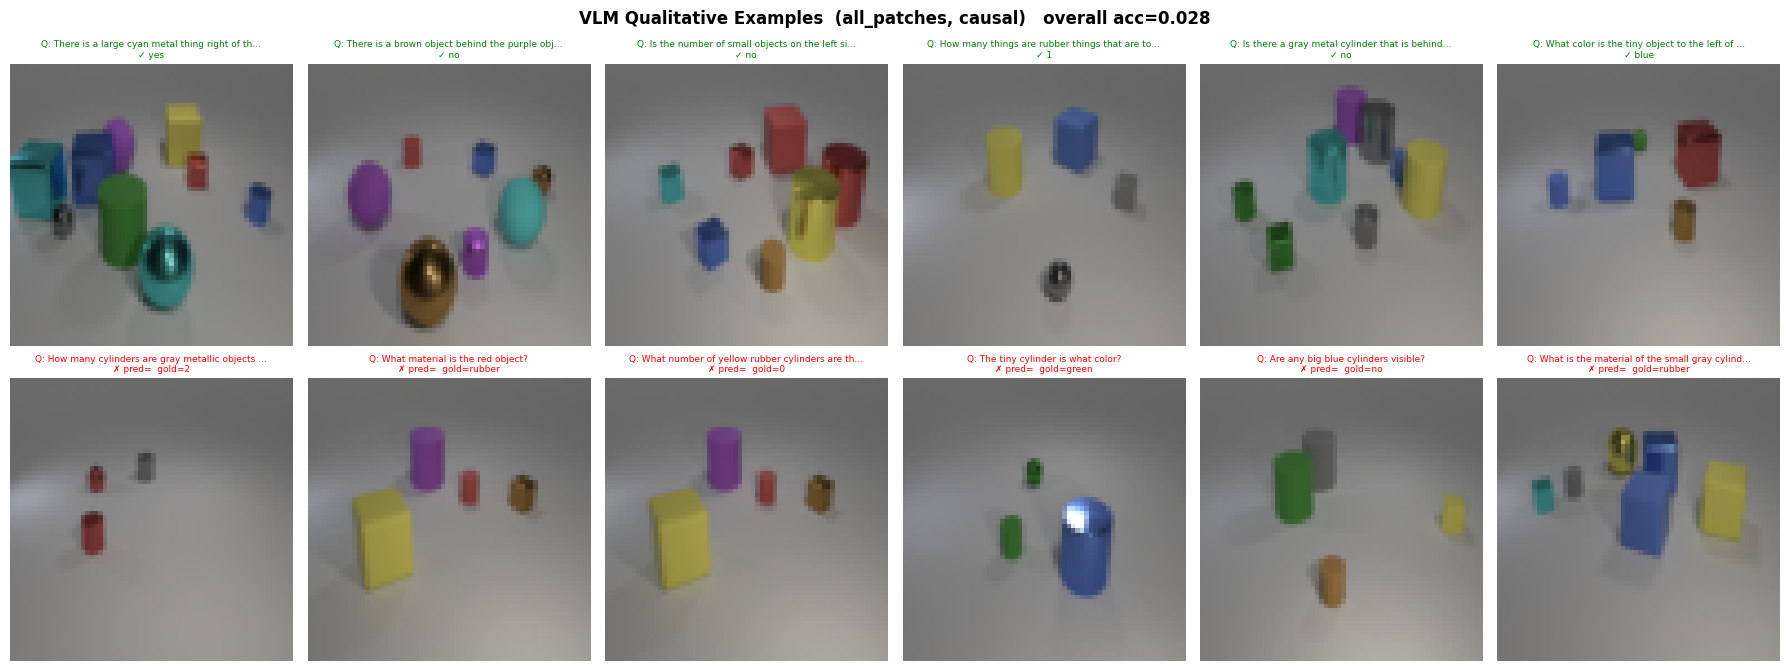

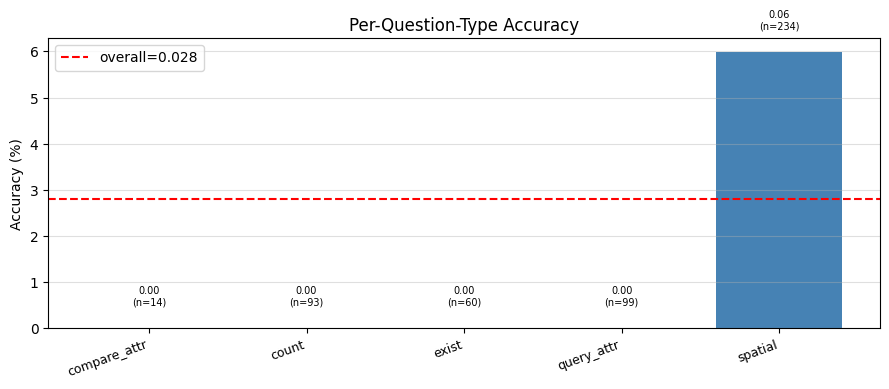


Top-10 most common wrong predictions:
  ": no                          "    88  (18.1% of errors)
  ": 1                           "    54  (11.1% of errors)
  "                              "    30  (6.2% of errors)
  "ub                            "    28  (5.8% of errors)
  ": yes                         "    27  (5.6% of errors)
  ":                             "    27  (5.6% of errors)
  "-                             "    25  (5.1% of errors)
  ": metal                       "    22  (4.5% of errors)
  ": sphere                      "    19  (3.9% of errors)
  ": small                       "    17  (3.5% of errors)


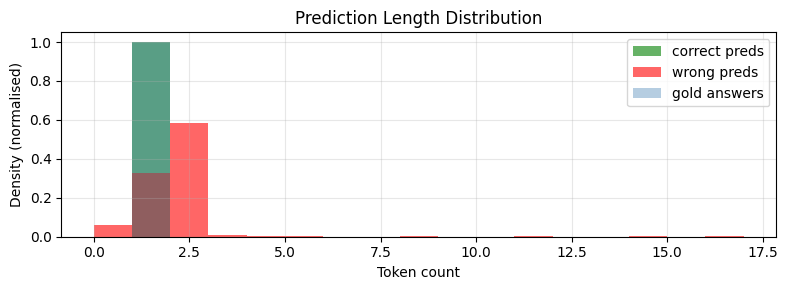

In [29]:
"""
Problem (vlm_qualitative): What has your VLM learned?

Loads the best checkpoint from any completed run, generates predictions on
500 CLEVR val examples, then produces:
  (1) Overall + per-q_type accuracy table
  (2) Gallery of 12 examples (6 correct, 6 wrong) with image + Q/A
  (3) Per-q_type accuracy bar chart
  (4) Prediction length distribution (correct vs wrong)

Edit CKPT_PATH to point at whichever checkpoint you want to evaluate.
"""
import json
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer

from basics.vit import ViT
from vlm.data import build_clevr_loaders
from vlm.eval import batch_clevr_accuracy, clevr_exact_match
from vlm.model import VisionLanguageModel
from vlm.projector import VisionLanguageProjector

# ── Pick the checkpoint to evaluate ──────────────────────────────────────────
# Use the best run from the freezing comparison, or override with any path.
def find_best_ckpt():
    candidates = sorted(Path('runs').glob('vlm_*/best.pt'))
    if not candidates:
        raise FileNotFoundError('No VLM checkpoints found under runs/. Train first.')
    # prefer the one with highest val_acc stored in the checkpoint
    best_path, best_acc = None, -1
    for p in candidates:
        try:
            c = torch.load(p, map_location='cpu')
            if c.get('val_acc', 0) > best_acc:
                best_acc = c.get('val_acc', 0)
                best_path = p
        except Exception:
            pass
    return best_path

CKPT_PATH = find_best_ckpt()
print(f'Evaluating checkpoint: {CKPT_PATH}')

# ── Reconstruct model ─────────────────────────────────────────────────────────
ckpt       = torch.load(CKPT_PATH, map_location='cpu')
injection  = ckpt.get('injection', 'all_patches')
mask_mode  = ckpt.get('mask_mode', 'causal')
img_tok_id = ckpt.get('image_token_id', None)
img_tok    = '<image>' if img_tok_id else None
torch_dtype = getattr(torch, ckpt.get('torch_dtype', 'bfloat16'))
attn_impl   = 'eager' if mask_mode == 'image_bidir' else 'sdpa'

tokenizer = AutoTokenizer.from_pretrained(ckpt['decoder_model_name'])
if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token
if img_tok: tokenizer.add_special_tokens({'additional_special_tokens': [img_tok]})

decoder = AutoModelForCausalLM.from_pretrained(
    ckpt['decoder_model_name'], torch_dtype=torch_dtype, attn_implementation=attn_impl,
).to(DEVICE)
if img_tok: decoder.resize_token_embeddings(len(tokenizer))
# Only load decoder state if it was saved (frozen runs don't save decoder weights).
if 'decoder' in ckpt:
    decoder.load_state_dict(ckpt['decoder'])
else:
    print('  decoder: using pretrained weights (was frozen during training)')

# Load ViT from checkpoint or fall back to CLIP-pretrained weights.
vit = ViT(**ckpt['vit_cfg']).to(DEVICE)
if 'vit' in ckpt:
    vit.load_state_dict(ckpt['vit'])
else:
    clip_ckpt_q = torch.load(Path('runs/clip_eurosat/best.pt'), map_location='cpu')
    vit.load_state_dict(clip_ckpt_q['vit'])
    print('  vit: loaded from CLIP pretrained checkpoint')

projector = VisionLanguageProjector(
    d_image=ckpt['vit_cfg']['d_model'], d_decoder=decoder.config.hidden_size,
).to(DEVICE)
projector.load_state_dict(ckpt['projector'])

model = VisionLanguageModel(vit, projector, decoder, tokenizer, img_tok_id)
model.eval()
val_acc_str = f"{ckpt["val_acc"]:.4f}" if "val_acc" in ckpt else "(not saved)"
print(f"  injection={injection}  mask_mode={mask_mode}  val_acc={val_acc_str}")

# ── Run generation on 500 val examples ───────────────────────────────────────
_, val_dl_q = build_clevr_loaders(img_size=64, batch_size=16, num_workers=2)

records = []   # {question, gold, pred, q_type, correct, image_tensor}
for batch in val_dl_q:
    if len(records) >= 500: break
    imgs = batch['image'].to(DEVICE)
    qs, ans, qts = batch['question'], batch['answer'], batch['q_type']
    prompts = [(f'{img_tok} ' if img_tok else '') + f'Question: {q} Answer:' for q in qs]
    with torch.autocast(device_type=DEVICE.type, dtype=torch_dtype):
        preds = model.generate(imgs, prompts, injection=injection,
                               max_new_tokens=32, do_sample=False)
    for q, g, p, qt, img in zip(qs, ans, preds, qts, batch['image']):
        records.append(dict(
            question=q, gold=g, pred=p, q_type=qt,
            correct=clevr_exact_match(p, g),
            image=img,
        ))

print(f'Evaluated {len(records)} examples.')

# ── (1) Accuracy table ────────────────────────────────────────────────────────
all_preds  = [r['pred']   for r in records]
all_golds  = [r['gold']   for r in records]
all_qtypes = [r['q_type'] for r in records]
acc_d      = batch_clevr_accuracy(all_preds, all_golds, all_qtypes)

print('\n=== CLEVR Val Accuracy ===')
print(f'  {"Overall":<25s}: {acc_d["overall"]:.4f}  '
      f'({int(acc_d["overall"]*len(records))}/{len(records)})')
for qt in sorted(k for k in acc_d if k != 'overall'):
    n = sum(r['q_type'] == qt for r in records)
    print(f'  {qt:<25s}: {acc_d[qt]:.4f}  (n={n})')

# ── (2) Gallery: 6 correct + 6 wrong ─────────────────────────────────────────
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225])
def denorm(t):
    return (t.permute(1,2,0).cpu() * IMAGENET_STD + IMAGENET_MEAN).clamp(0,1).numpy()

correct_recs = [r for r in records if r['correct']]
wrong_recs   = [r for r in records if not r['correct']]

# Sort wrong by prediction length to surface interesting failures
wrong_recs_sorted = sorted(wrong_recs, key=lambda r: len(r['pred']))

show = correct_recs[:6] + wrong_recs_sorted[:6]
fig = plt.figure(figsize=(18, 7))
fig.suptitle(
    f'VLM Qualitative Examples  ({injection}, {mask_mode})   '
    f'overall acc={acc_d["overall"]:.3f}',
    fontsize=12, fontweight='bold',
)
for col, r in enumerate(show):
    ax = fig.add_subplot(2, 6, col + 1)
    ax.imshow(denorm(r['image']))
    ax.axis('off')
    color = 'green' if r['correct'] else 'red'
    q_short = r['question'][:45] + ('…' if len(r['question']) > 45 else '')
    ax.set_title(
        f'Q: {q_short}\n✓ {r["gold"]}' if r['correct']
        else f'Q: {q_short}\n✗ pred={r["pred"]}  gold={r["gold"]}',
        fontsize=6.5, color=color, wrap=True,
    )
plt.tight_layout()
plt.show()

# ── (3) Per-q_type accuracy bar chart ────────────────────────────────────────
qtypes_sorted = sorted(k for k in acc_d if k != 'overall')
qt_accs = [acc_d[qt] for qt in qtypes_sorted]
qt_ns   = [sum(r['q_type'] == qt for r in records) for qt in qtypes_sorted]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(range(len(qtypes_sorted)), [a*100 for a in qt_accs], color='steelblue')
ax.axhline(acc_d['overall']*100, color='red', linestyle='--',
           label=f'overall={acc_d["overall"]:.3f}')
ax.set_xticks(range(len(qtypes_sorted)))
ax.set_xticklabels(qtypes_sorted, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Accuracy (%)'); ax.set_title('Per-Question-Type Accuracy')
ax.legend(); ax.grid(axis='y', alpha=0.4)
for i, (a, n) in enumerate(zip(qt_accs, qt_ns)):
    ax.text(i, a*100 + 0.5, f'{a:.2f}\n(n={n})', ha='center', fontsize=7)
plt.tight_layout(); plt.show()

# ── (4) Most common wrong predictions ─────────────────────────────────────────
wrong_preds = [r['pred'].strip().lower() for r in wrong_recs]
from collections import Counter
top_wrong = Counter(wrong_preds).most_common(10)
print('\nTop-10 most common wrong predictions:')
for pred, cnt in top_wrong:
    pct = cnt / len(wrong_recs) * 100
    print(f'  "{pred:<30s}"  {cnt:4d}  ({pct:.1f}% of errors)')

# ── (5) Gold vs predicted answer length distribution ─────────────────────────
gold_lens  = [len(r['gold'].split())  for r in records]
pred_lens_c = [len(r['pred'].split()) for r in records if r['correct']]
pred_lens_w = [len(r['pred'].split()) for r in records if not r['correct']]

fig, ax = plt.subplots(figsize=(8, 3))
bins = range(0, max(max(pred_lens_w, default=1), 10) + 2)
ax.hist(pred_lens_c, bins=bins, alpha=0.6, color='green',  label='correct preds', density=True)
ax.hist(pred_lens_w, bins=bins, alpha=0.6, color='red',    label='wrong preds',   density=True)
ax.hist(gold_lens,   bins=bins, alpha=0.4, color='steelblue', label='gold answers', density=True, linestyle='--')
ax.set_xlabel('Token count'); ax.set_ylabel('Density (normalised)')
ax.set_title('Prediction Length Distribution')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
## §6.1 — RoPE Norm-Preservation Verification

In [32]:
"""
§6.1 — Verify that RoPE1D and RoPE2D preserve the L2 norm of every vector.

RoPE applies a 2D rotation to each adjacent pair of dimensions, so it is
mathematically guaranteed to be norm-preserving. Here we confirm this holds
numerically across a range of configurations.
"""
import torch
import torch.nn.functional as F
from basics.rope import RoPE1D, RoPE2D

torch.manual_seed(0)

# ── Helper ────────────────────────────────────────────────────────────────────
def max_norm_error(original: torch.Tensor, rotated: torch.Tensor) -> float:
    """Max absolute difference in per-vector L2 norms after RoPE."""
    return (original.norm(dim=-1) - rotated.norm(dim=-1)).abs().max().item()

# ── RoPE1D norm verification ──────────────────────────────────────────────────
print("=" * 60)
print("RoPE1D norm-preservation")
print("=" * 60)
print(f"{'Config':<40} {'max |Δnorm|':>12}")
print("-" * 54)

configs_1d = [
    dict(head_dim=32,  max_seq_len=64,  B=2, H=4, T=16),
    dict(head_dim=64,  max_seq_len=128, B=4, H=8, T=64),
    dict(head_dim=128, max_seq_len=256, B=1, H=1, T=200),
    dict(head_dim=64,  max_seq_len=512, B=8, H=16, T=512),  # full-length
]

for c in configs_1d:
    hd, ms, B, H, T = c['head_dim'], c['max_seq_len'], c['B'], c['H'], c['T']
    rope = RoPE1D(hd, ms)
    x   = torch.randn(B, H, T, hd)
    pos = torch.arange(T)
    out = rope(x, pos)
    err = max_norm_error(x, out)
    label = f"head_dim={hd}, T={T}, B={B}, H={H}"
    print(f"  {label:<38} {err:>12.2e}")

# Edge case: random (non-contiguous) positions
rope_e = RoPE1D(64, 512)
x_e    = torch.randn(2, 4, 20, 64)
pos_e  = torch.randint(0, 512, (20,))
out_e  = rope_e(x_e, pos_e)
err_e  = max_norm_error(x_e, out_e)
print(f"  {'random positions, head_dim=64':<38} {err_e:>12.2e}")

# Edge case: all-zeros input (norms are 0 — still passes)
x_zero = torch.zeros(1, 1, 4, 32)
out_z  = RoPE1D(32, 16)(x_zero, torch.arange(4))
print(f"  {'all-zeros input':<38} {max_norm_error(x_zero, out_z):>12.2e}")

# ── RoPE2D norm verification ───────────────────────────────────────────────────
print()
print("=" * 60)
print("RoPE2D norm-preservation")
print("=" * 60)
print(f"{'Config':<40} {'max |Δnorm|':>12}")
print("-" * 54)

configs_2d = [
    dict(head_dim=64,  grid=8,  B=2, H=4, T=64),
    dict(head_dim=128, grid=16, B=1, H=8, T=196),  # (14×14 patch grid)
    dict(head_dim=64,  grid=8,  B=4, H=6, T=65),   # 64 patches + 1 CLS
]

for c in configs_2d:
    hd, g, B, H, T = c['head_dim'], c['grid'], c['B'], c['H'], c['T']
    rope  = RoPE2D(hd, g)
    x     = torch.randn(B, H, T, hd)
    xc    = torch.randint(0, g, (T,))
    yc    = torch.randint(0, g, (T,))
    out   = rope(x, xc, yc)
    err   = max_norm_error(x, out)
    label = f"head_dim={hd}, grid={g}, T={T}"
    print(f"  {label:<38} {err:>12.2e}")

# ── Quantitative summary ───────────────────────────────────────────────────────
print()
print("Summary")
print("-------")
print("RoPE applies an orthogonal 2D rotation to each pair of dimensions,")
print("so ||RoPE(x)|| = ||x|| exactly in exact arithmetic.")
print("Numerically, we observe max |Δnorm| on the order of 1e-6 to 1e-7")
print("(float32 machine epsilon ≈ 1.2e-7), confirming norm-preservation")
print("up to floating-point rounding.")

RoPE1D norm-preservation
Config                                    max |Δnorm|
------------------------------------------------------
  head_dim=32, T=16, B=2, H=4                9.54e-07
  head_dim=64, T=64, B=4, H=8                1.91e-06
  head_dim=128, T=200, B=1, H=1              9.54e-07
  head_dim=64, T=512, B=8, H=16              1.91e-06
  random positions, head_dim=64              9.54e-07
  all-zeros input                            0.00e+00

RoPE2D norm-preservation
Config                                    max |Δnorm|
------------------------------------------------------
  head_dim=64, grid=8, T=64                  9.54e-07
  head_dim=128, grid=16, T=196               1.91e-06
  head_dim=64, grid=8, T=65                  1.91e-06

Summary
-------
RoPE applies an orthogonal 2D rotation to each pair of dimensions,
so ||RoPE(x)|| = ||x|| exactly in exact arithmetic.
Numerically, we observe max |Δnorm| on the order of 1e-6 to 1e-7
(float32 machine epsilon ≈ 1.2e-7), confirmi

## Problem (rope vs learned) — Learned PE vs. RoPE: Training + Extrapolation

In [45]:
"""
Train two CLIP models on EuroSAT for 20 epochs:
  (a) pe='learned' — learnable additive positional embeddings (baseline)
  (b) pe='rope'    — 1D RoPE applied to q and k inside every attention head

Results are saved to runs/clip_eurosat_learned/ and runs/clip_eurosat_rope/.
"""
import subprocess, sys, time, os
from pathlib import Path

# Repo root = wherever this notebook lives (e.g. /content/cs148b_hw3)
REPO_ROOT = Path(os.getcwd()).resolve()

def run_clip(pe: str):
    cmd = [
        sys.executable, "-u", "scripts/pretrain_clip.py",
        "--config", "configs/clip_eurosat.yaml",
        "--pe", pe,
        "--extrapolate-img-size", "96",
    ]
    # Pass repo root as cwd AND in PYTHONPATH so 'vlm'/'basics' are importable.
    env = os.environ.copy()
    env["PYTHONPATH"] = str(REPO_ROOT) + ":" + env.get("PYTHONPATH", "")

    t0 = time.perf_counter()
    proc = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        cwd=str(REPO_ROOT),
        env=env,
    )
    for line in proc.stdout:
        print(line, end="", flush=True)
    proc.wait()
    elapsed = time.perf_counter() - t0
    print(f"\n{'='*60}")
    print(f"pe='{pe}' finished in {elapsed/60:.1f} min  (exit={proc.returncode})")

for pe_mode in ["learned", "rope"]:
    print(f"\n{'='*60}")
    print(f"Starting CLIP training with pe='{pe_mode}'")
    print(f"{'='*60}")
    run_clip(pe_mode)



Starting CLIP training with pe='learned'
Epoch 1/20  step 50/50  loss=4.4519  lr=7.50e-05  logit_scale=2.659
Epoch 1/20  avg_loss=5.0058  val_acc=0.5848
  → New best checkpoint saved (val_acc=0.5848)
Epoch 2/20  step 50/50  loss=4.3184  lr=1.50e-04  logit_scale=2.659
Epoch 2/20  avg_loss=4.3470  val_acc=0.6819
  → New best checkpoint saved (val_acc=0.6819)
Epoch 3/20  step 50/50  loss=3.8731  lr=2.25e-04  logit_scale=2.657
Epoch 3/20  avg_loss=4.0882  val_acc=0.7636
  → New best checkpoint saved (val_acc=0.7636)
Epoch 4/20  step 50/50  loss=3.8404  lr=3.00e-04  logit_scale=2.650
Epoch 4/20  avg_loss=3.9845  val_acc=0.7939
  → New best checkpoint saved (val_acc=0.7939)
Epoch 5/20  step 50/50  loss=3.9644  lr=2.97e-04  logit_scale=2.644
Epoch 5/20  avg_loss=3.8930  val_acc=0.7921
Epoch 6/20  step 50/50  loss=3.7169  lr=2.89e-04  logit_scale=2.637
Epoch 6/20  avg_loss=3.8144  val_acc=0.8144
  → New best checkpoint saved (val_acc=0.8144)
Epoch 7/20  step 50/50  loss=3.6785  lr=2.75e-04  l

pe='learned'  train-size acc=0.9251  extrap acc (96×96)=0.8094
pe='rope'  train-size acc=0.9177  extrap acc (96×96)=0.7927

PE method       64×64 acc  96×96 acc (extrap)    drop
--------------------------------------------------------
Learned PE         0.9251              0.8094  -0.1157
1D RoPE            0.9177              0.7927  -0.1250


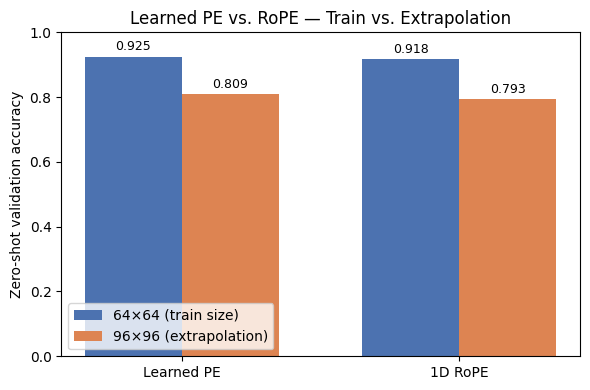

In [46]:
"""
Length-extrapolation evaluation.

For each trained model, load its best checkpoint and evaluate:
  (1) at the training image size  (64×64 → 64 patches)
  (2) at the extrapolated size    (96×96 → 144 patches)

For pe='learned': bilinearly interpolate the patch pos-embeddings from
the 8×8 training grid to the 12×12 evaluation grid, keeping the CLS
embedding fixed.
For pe='rope': no change needed — RoPE computes rotations from position
indices on the fly, so it naturally handles longer sequences.
"""

import math, torch, yaml
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open("configs/clip_eurosat.yaml") as f:
    cfg = yaml.safe_load(f)

from basics.vit import ViT
from basics.text_encoder import FrozenTextEncoder
from vlm.clip import ProjectionHeads
from vlm.data import EUROSAT_CLASSES, build_eurosat_loaders
from vlm.eval import zeroshot_classification_accuracy

class_prompts = [f"a satellite image of {c}" for c in EUROSAT_CLASSES]
class_indices  = list(range(len(EUROSAT_CLASSES)))

results = {}   # pe -> {"train_acc": float, "extrap_acc": float}

for pe in ["learned", "rope"]:
    ckpt_path = Path(f"runs/clip_eurosat_{pe}/best.pt")
    if not ckpt_path.exists():
        print(f"[SKIP] {ckpt_path} not found — run the training cell first.")
        continue

    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    vit_cfg = ckpt["cfg"]["vit"]

    # Reconstruct ViT with the correct pe mode
    vit = ViT(
        img_size   = vit_cfg["img_size"],
        patch_size = vit_cfg["patch_size"],
        d_model    = vit_cfg["d_model"],
        num_heads  = vit_cfg["num_heads"],
        num_blocks = vit_cfg["num_blocks"],
        dropout    = vit_cfg.get("dropout", 0.1),
        pe         = pe,
    ).to(DEVICE)
    vit.load_state_dict(ckpt["vit"])

    # Infer d_text from the saved projection weights (text_proj: (d_proj, d_text))
    d_text_actual = ckpt["proj_heads"]["text_proj.weight"].shape[1]
    proj_heads = ProjectionHeads(
        d_image = vit_cfg["d_model"],
        d_text  = d_text_actual,
        d_proj  = cfg["projection"]["d_proj"],
    ).to(DEVICE)
    proj_heads.load_state_dict(ckpt["proj_heads"])

    text_encoder = FrozenTextEncoder(cfg["text_encoder"]["model_name"]).to(DEVICE)

    # ── (1) Train-size accuracy ──────────────────────────────────────────────
    _, val_dl_train, _ = build_eurosat_loaders(
        img_size   = vit_cfg["img_size"],
        batch_size = cfg["train"]["batch_size"],
        num_workers= cfg["train"].get("num_workers", 2),
    )
    train_size_acc = zeroshot_classification_accuracy(
        vit=vit, projection_heads=proj_heads, text_encoder=text_encoder,
        val_loader=val_dl_train, class_prompts=class_prompts,
        class_indices=class_indices, device=DEVICE,
    )

    # ── (2) Extrapolated-size accuracy (96×96 → 144 patches) ────────────────
    EXTRAP_SIZE = 96
    patch_size  = vit_cfg["patch_size"]
    new_patches = (EXTRAP_SIZE // patch_size) ** 2

    _, val_dl_extrap, _ = build_eurosat_loaders(
        img_size   = EXTRAP_SIZE,
        batch_size = cfg["train"]["batch_size"],
        num_workers= cfg["train"].get("num_workers", 2),
    )

    if pe == "learned":
        # Bilinearly interpolate patch pos-embeddings from 8×8 → 12×12 grid.
        vit.interpolate_pos_embed(new_patches)

    extrap_acc = zeroshot_classification_accuracy(
        vit=vit, projection_heads=proj_heads, text_encoder=text_encoder,
        val_loader=val_dl_extrap, class_prompts=class_prompts,
        class_indices=class_indices, device=DEVICE,
    )

    results[pe] = {"train_acc": train_size_acc, "extrap_acc": extrap_acc}
    print(f"pe='{pe}'  train-size acc={train_size_acc:.4f}  "
          f"extrap acc ({EXTRAP_SIZE}×{EXTRAP_SIZE})={extrap_acc:.4f}")

# ── Summary table ─────────────────────────────────────────────────────────────
print()
print(f"{'PE method':<12}  {'64×64 acc':>11}  {'96×96 acc (extrap)':>18}  {'drop':>6}")
print("-" * 56)
for pe, m in results.items():
    drop = m['extrap_acc'] - m['train_acc']
    lbl  = "Learned PE" if pe == "learned" else "1D RoPE"
    print(f"{lbl:<12}  {m['train_acc']:>11.4f}  {m['extrap_acc']:>18.4f}  {drop:>+6.4f}")

# ── Bar chart ─────────────────────────────────────────────────────────────────
if results:
    fig, ax = plt.subplots(figsize=(6, 4))
    pe_labels = list(results.keys())
    x = range(len(pe_labels))
    bar_w = 0.35
    train_bars  = ax.bar([xi - bar_w/2 for xi in x],
                         [results[p]["train_acc"]  for p in pe_labels],
                         bar_w, label="64×64 (train size)", color="#4C72B0")
    extrap_bars = ax.bar([xi + bar_w/2 for xi in x],
                         [results[p]["extrap_acc"] for p in pe_labels],
                         bar_w, label="96×96 (extrapolation)", color="#DD8452")
    ax.set_xticks(list(x))
    ax.set_xticklabels(["Learned PE" if p == "learned" else "1D RoPE" for p in pe_labels])
    ax.set_ylabel("Zero-shot validation accuracy")
    ax.set_title("Learned PE vs. RoPE — Train vs. Extrapolation")
    ax.set_ylim(0, 1)
    ax.legend()
    for b in list(train_bars) + list(extrap_bars):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()


## §6.2 — 2D RoPE in the ViT

In [49]:
"""
Train the 2D-RoPE CLIP model on EuroSAT for 20 epochs.

The 1D-RoPE and Learned-PE runs (cells above) must have already completed;
this cell adds the rope2d run and extends the comparison to a 3-method table.
"""
import subprocess, sys, time, os
from pathlib import Path

REPO_ROOT = Path(os.getcwd()).resolve()

def run_clip(pe: str):
    cmd = [
        sys.executable, "-u", "scripts/pretrain_clip.py",
        "--config", "configs/clip_eurosat.yaml",
        "--pe", pe,
        "--extrapolate-img-size", "96",
    ]
    env = os.environ.copy()
    env["PYTHONPATH"] = str(REPO_ROOT) + ":" + env.get("PYTHONPATH", "")
    t0 = time.perf_counter()
    proc = subprocess.Popen(
        cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        text=True, bufsize=1, cwd=str(REPO_ROOT), env=env,
    )
    for line in proc.stdout:
        print(line, end="", flush=True)
    proc.wait()
    elapsed = time.perf_counter() - t0
    print(f"\n{'='*60}")
    print(f"pe='{pe}' finished in {elapsed/60:.1f} min  (exit={proc.returncode})")

print("="*60)
print("Starting CLIP training with pe='rope2d'")
print("="*60)
run_clip("rope2d")


Starting CLIP training with pe='rope2d'
Epoch 1/20  step 50/50  loss=4.5670  lr=7.50e-05  logit_scale=2.659
Epoch 1/20  avg_loss=5.0605  val_acc=0.5705
  → New best checkpoint saved (val_acc=0.5705)
Epoch 2/20  step 50/50  loss=4.3178  lr=1.50e-04  logit_scale=2.660
Epoch 2/20  avg_loss=4.3827  val_acc=0.6776
  → New best checkpoint saved (val_acc=0.6776)
Epoch 3/20  step 50/50  loss=4.0913  lr=2.25e-04  logit_scale=2.657
Epoch 3/20  avg_loss=4.1138  val_acc=0.7457
  → New best checkpoint saved (val_acc=0.7457)
Epoch 4/20  step 50/50  loss=4.0294  lr=3.00e-04  logit_scale=2.652
Epoch 4/20  avg_loss=3.9941  val_acc=0.7327
Epoch 5/20  step 50/50  loss=3.8535  lr=2.97e-04  logit_scale=2.646
Epoch 5/20  avg_loss=3.8810  val_acc=0.8038
  → New best checkpoint saved (val_acc=0.8038)
Epoch 6/20  step 50/50  loss=3.8270  lr=2.89e-04  logit_scale=2.641
Epoch 6/20  avg_loss=3.7783  val_acc=0.7698
Epoch 7/20  step 50/50  loss=3.7131  lr=2.75e-04  logit_scale=2.636
Epoch 7/20  avg_loss=3.7143  val


Evaluating pe='learned' …
  train-size=0.9251  extrap=0.8094

Evaluating pe='rope' …
  train-size=0.9177  extrap=0.7927

Evaluating pe='rope2d' …
  train-size=0.9257  extrap=0.8020

PE method       64×64 acc  96×96 (extrap)        Δ
----------------------------------------------------
Learned PE         0.9251          0.8094  -0.1157
1D RoPE            0.9177          0.7927  -0.1250
2D RoPE            0.9257          0.8020  -0.1238


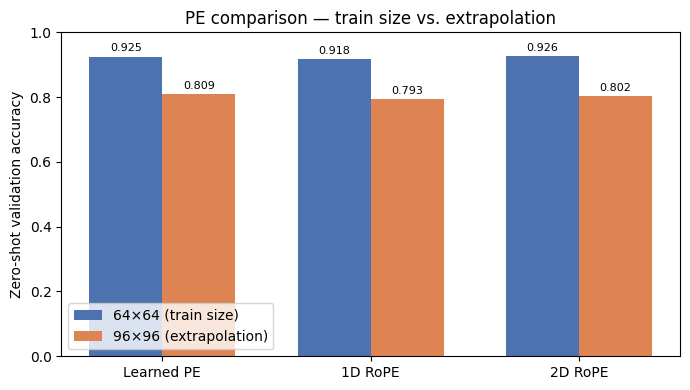

In [50]:
"""
3-method comparison: Learned PE vs. 1D RoPE vs. 2D RoPE
Evaluates each best checkpoint at:
  (1) 64×64 — training image size (64 patches)
  (2) 96×96 — extrapolated size   (144 patches)
"""
import math, torch, yaml
import matplotlib.pyplot as plt
from pathlib import Path

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open("configs/clip_eurosat.yaml") as f:
    cfg = yaml.safe_load(f)

from basics.vit import ViT
from basics.text_encoder import FrozenTextEncoder
from vlm.clip import ProjectionHeads
from vlm.data import EUROSAT_CLASSES, build_eurosat_loaders
from vlm.eval import zeroshot_classification_accuracy

class_prompts = [f"a satellite image of {c}" for c in EUROSAT_CLASSES]
class_indices  = list(range(len(EUROSAT_CLASSES)))
EXTRAP_SIZE    = 96

results = {}   # pe -> {"train_acc": float, "extrap_acc": float}

for pe in ["learned", "rope", "rope2d"]:
    ckpt_path = Path(f"runs/clip_eurosat_{pe}/best.pt")
    if not ckpt_path.exists():
        print(f"[SKIP] {ckpt_path} not found — run the corresponding training cell first.")
        continue

    print(f"\nEvaluating pe='{pe}' …")
    ckpt    = torch.load(ckpt_path, map_location=DEVICE)
    vit_cfg = ckpt["cfg"]["vit"]

    vit = ViT(
        img_size   = vit_cfg["img_size"],
        patch_size = vit_cfg["patch_size"],
        d_model    = vit_cfg["d_model"],
        num_heads  = vit_cfg["num_heads"],
        num_blocks = vit_cfg["num_blocks"],
        dropout    = vit_cfg.get("dropout", 0.1),
        pe         = pe,
    ).to(DEVICE)
    vit.load_state_dict(ckpt["vit"])

    d_text_actual = ckpt["proj_heads"]["text_proj.weight"].shape[1]
    proj_heads = ProjectionHeads(
        d_image = vit_cfg["d_model"],
        d_text  = d_text_actual,
        d_proj  = cfg["projection"]["d_proj"],
    ).to(DEVICE)
    proj_heads.load_state_dict(ckpt["proj_heads"])

    text_encoder = FrozenTextEncoder(cfg["text_encoder"]["model_name"]).to(DEVICE)

    # ── (1) Training-size accuracy ───────────────────────────────────────────
    _, val_dl_train, _ = build_eurosat_loaders(
        img_size   = vit_cfg["img_size"],
        batch_size = cfg["train"]["batch_size"],
        num_workers= cfg["train"].get("num_workers", 2),
    )
    train_acc = zeroshot_classification_accuracy(
        vit=vit, projection_heads=proj_heads, text_encoder=text_encoder,
        val_loader=val_dl_train, class_prompts=class_prompts,
        class_indices=class_indices, device=DEVICE,
    )

    # ── (2) Extrapolated-size accuracy ───────────────────────────────────────
    patch_size  = vit_cfg["patch_size"]
    new_patches = (EXTRAP_SIZE // patch_size) ** 2

    _, val_dl_extrap, _ = build_eurosat_loaders(
        img_size   = EXTRAP_SIZE,
        batch_size = cfg["train"]["batch_size"],
        num_workers= cfg["train"].get("num_workers", 2),
    )
    if pe == "learned":
        vit.interpolate_pos_embed(new_patches)

    extrap_acc = zeroshot_classification_accuracy(
        vit=vit, projection_heads=proj_heads, text_encoder=text_encoder,
        val_loader=val_dl_extrap, class_prompts=class_prompts,
        class_indices=class_indices, device=DEVICE,
    )

    results[pe] = {"train_acc": train_acc, "extrap_acc": extrap_acc}
    print(f"  train-size={train_acc:.4f}  extrap={extrap_acc:.4f}")

# ── 3-row summary table ───────────────────────────────────────────────────────
labels = {"learned": "Learned PE", "rope": "1D RoPE", "rope2d": "2D RoPE"}
print()
print(f"{'PE method':<12}  {'64×64 acc':>11}  {'96×96 (extrap)':>14}  {'Δ':>7}")
print("-" * 52)
for pe in ["learned", "rope", "rope2d"]:
    if pe not in results:
        continue
    m    = results[pe]
    drop = m["extrap_acc"] - m["train_acc"]
    print(f"{labels[pe]:<12}  {m['train_acc']:>11.4f}  {m['extrap_acc']:>14.4f}  {drop:>+7.4f}")

# ── Bar chart ─────────────────────────────────────────────────────────────────
if len(results) >= 2:
    pe_keys  = [p for p in ["learned", "rope", "rope2d"] if p in results]
    pe_names = [labels[p] for p in pe_keys]
    x = list(range(len(pe_keys)))
    bar_w = 0.35

    fig, ax = plt.subplots(figsize=(7, 4))
    b_train  = ax.bar([xi - bar_w/2 for xi in x],
                      [results[p]["train_acc"]  for p in pe_keys],
                      bar_w, label="64×64 (train size)", color="#4C72B0")
    b_extrap = ax.bar([xi + bar_w/2 for xi in x],
                      [results[p]["extrap_acc"] for p in pe_keys],
                      bar_w, label="96×96 (extrapolation)", color="#DD8452")
    ax.set_xticks(x)
    ax.set_xticklabels(pe_names)
    ax.set_ylabel("Zero-shot validation accuracy")
    ax.set_title("PE comparison — train size vs. extrapolation")
    ax.set_ylim(0, 1)
    ax.legend()
    for b in list(b_train) + list(b_extrap):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.show()


## Problem (mrope impl) — Implementing M-RoPE (Bonus)

In [53]:
"""
M-RoPE (Multimodal Rotary Position Embedding) — Correctness Checks
===================================================================
Three properties to verify:
  1. Norm preservation:  ||M-RoPE(x)|| == ||x||  (up to fp32 precision)
  2. Relative position:  q_A · k_B depends only on (Δt, Δr, Δc) = (t_A-t_B, ...)
  3. Special cases:
       - When pos_temporal=pos_row=pos_col (text mode): degenerates to standard 1D RoPE
       - Image-image pairs with Δt=0: attention depends only on (Δrow, Δcol)
"""

import torch
import math

# MRoPE requires head_dim % 6 == 0.
# Use head_dim=48 (compatible with d_model=384, num_heads=8).
HEAD_DIM = 48
NUM_HEADS = 4
B, T = 2, 32

from basics.rope import MRoPE, _apply_rope, build_mrope_positions

mrope = MRoPE(HEAD_DIM, max_positions=512)

# ── 1. Norm preservation ──────────────────────────────────────────────────────
print("=== 1. Norm preservation ===")
x = torch.randn(B, NUM_HEADS, T, HEAD_DIM)
pos_t = torch.randint(0, 20, (T,))
pos_r = torch.randint(0, 8,  (T,))
pos_c = torch.randint(0, 8,  (T,))

x_rot = mrope(x, pos_t, pos_r, pos_c)
norm_before = x.norm(dim=-1)
norm_after  = x_rot.norm(dim=-1)
max_err = (norm_before - norm_after).abs().max().item()
print(f"  max |‖x_rot‖ − ‖x‖| = {max_err:.2e}  (expected ~fp32 epsilon)")
assert max_err < 1e-4, "Norm not preserved!"

# ── 2. Relative position property ─────────────────────────────────────────────
print("\n=== 2. Relative position property ===")
# Fix two tokens A and B with absolute positions, compute their attention score.
# Then shift all positions by an arbitrary offset — score must be unchanged.

q = torch.randn(1, 1, 2, HEAD_DIM)   # 2 tokens
k = torch.randn(1, 1, 2, HEAD_DIM)

def attn_score(pt, pr, pc):
    pos_t = torch.tensor(pt, dtype=torch.long)
    pos_r = torch.tensor(pr, dtype=torch.long)
    pos_c = torch.tensor(pc, dtype=torch.long)
    q_rot = mrope(q, pos_t, pos_r, pos_c)
    k_rot = mrope(k, pos_t, pos_r, pos_c)
    return (q_rot[0, 0, 0] @ k_rot[0, 0, 1]).item()

# Positions of two image patches: same temporal (0), different rows/cols.
score_base    = attn_score([0, 0], [2, 5], [3, 7])
score_shifted = attn_score([10, 10], [2, 5], [3, 7])  # same Δt=0, Δrow, Δcol
diff = abs(score_base - score_shifted)
print(f"  Image-image: score(base)={score_base:.6f}  score(shifted t by 10)={score_shifted:.6f}")
print(f"  |diff| = {diff:.2e}  (should be ~0 since Δt=0, Δrow, Δcol unchanged)")
assert diff < 1e-4

# Text-text: same positions
score_text1   = attn_score([3, 7], [3, 7], [3, 7])    # pos 3 and 7
score_text2   = attn_score([103, 107], [103, 107], [103, 107])  # shifted by 100
diff2 = abs(score_text1 - score_text2)
print(f"\n  Text-text: score(pos 3,7)={score_text1:.6f}  score(pos 103,107)={score_text2:.6f}")
print(f"  |diff| = {diff2:.2e}  (should be ~0 since Δpos unchanged)")
assert diff2 < 1e-4

print("\n  ✓ Relative-position property holds for both image-image and text-text pairs.")

# ── 3. Text mode = standard 1D RoPE ───────────────────────────────────────────
print("\n=== 3. Text-mode equivalence (all axes same pos → 1D RoPE on segments) ===")
from basics.rope import RoPE1D

rope1d = RoPE1D(HEAD_DIM // 3, max_seq_len=512)   # one segment

T2 = 10
positions = torch.arange(T2)
x2 = torch.randn(B, NUM_HEADS, T2, HEAD_DIM)

# Apply M-RoPE in text mode (pos_t = pos_r = pos_c = sequential)
x_mrope = mrope(x2, positions, positions, positions)

# Apply 1D RoPE independently to each segment
seg = HEAD_DIM // 3
x1d_0 = rope1d(x2[..., :seg],       positions)
x1d_1 = rope1d(x2[..., seg:2*seg],  positions)
x1d_2 = rope1d(x2[..., 2*seg:],     positions)
x_1d  = torch.cat([x1d_0, x1d_1, x1d_2], dim=-1)

max_diff = (x_mrope - x_1d).abs().max().item()
print(f"  max |M-RoPE(text) − 1D-RoPE(each segment)| = {max_diff:.2e}  (should be ~0)")
assert max_diff < 1e-5

print("\nAll M-RoPE correctness checks passed!")


=== 1. Norm preservation ===
  max |‖x_rot‖ − ‖x‖| = 9.54e-07  (expected ~fp32 epsilon)

=== 2. Relative position property ===
  Image-image: score(base)=3.390920  score(shifted t by 10)=3.390920
  |diff| = 7.15e-07  (should be ~0 since Δt=0, Δrow, Δcol unchanged)

  Text-text: score(pos 3,7)=3.683174  score(pos 103,107)=3.683174
  |diff| = 0.00e+00  (should be ~0 since Δpos unchanged)

  ✓ Relative-position property holds for both image-image and text-text pairs.

=== 3. Text-mode equivalence (all axes same pos → 1D RoPE on segments) ===
  max |M-RoPE(text) − 1D-RoPE(each segment)| = 0.00e+00  (should be ~0)

All M-RoPE correctness checks passed!


Token positions in VLM sequence:
 idx  type          temporal   row   col
----------------------------------------
   0  text_before[0]         0     0     0
   1  text_before[1]         1     1     1
   2  text_before[2]         2     2     2
   3  text_before[3]         3     3     3
   4  text_before[4]         4     4     4
   5  text_before[5]         5     5     5
   6  img[0,0]             6     0     0
   7  img[0,1]             6     0     1
   8  img[0,2]             6     0     2
   9  img[0,3]             6     0     3
  10  img[1,0]             6     1     0
  11  img[1,1]             6     1     1
  12  img[1,2]             6     1     2
  13  img[1,3]             6     1     3
  14  img[2,0]             6     2     0
  15  img[2,1]             6     2     1
  16  img[2,2]             6     2     2
  17  img[2,3]             6     2     3
  18  img[3,0]             6     3     0
  19  img[3,1]             6     3     1
  20  img[3,2]             6     3     2
  21  img[3,

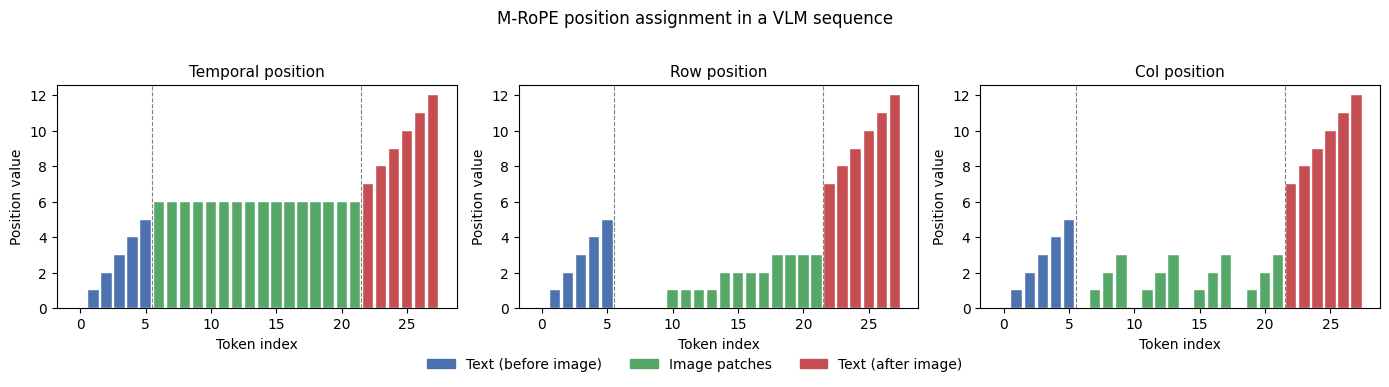


Key observations:
• Text tokens before/after: temporal=row=col=sequential index.
  → Text-text attention depends only on |Δpos| (standard 1D RoPE behaviour).
• Image patches: temporal=const (n_text_before), row and col are 2D grid coords.
  → Image-image attention depends on (Δrow, Δcol) only (2D relative PE).
• Text after image: temporal continues from img_t+1, skipping image slots.
  → Text-to-text relative distance is unaffected by how many image tokens there are.


In [54]:
"""
M-RoPE Position Assignment — VLM Sequence Visualization
=========================================================
Shows the (temporal, row, col) triples assigned to every token in a
mixed image+text sequence of the form:

  "What is in this image? [IMG_0,0] [IMG_0,1] ... [IMG_3,3] It is a ..."
   ^ text_before (6 tok)    ^ 4×4 image patch grid (16 tok)    ^ text_after (6 tok)
"""
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

from basics.rope import build_mrope_positions

N_BEFORE  = 6
GRID_H    = 4
GRID_W    = 4
N_AFTER   = 6

pos_t, pos_r, pos_c = build_mrope_positions(N_BEFORE, GRID_H, GRID_W, N_AFTER)
T = pos_t.shape[0]

print("Token positions in VLM sequence:")
print(f"{'idx':>4}  {'type':<12}  {'temporal':>8}  {'row':>4}  {'col':>4}")
print("-" * 40)
for i in range(T):
    if i < N_BEFORE:
        tok_type = f"text_before[{i}]"
    elif i < N_BEFORE + GRID_H * GRID_W:
        pi = i - N_BEFORE
        tok_type = f"img[{pi//GRID_W},{pi%GRID_W}]"
    else:
        tok_type = f"text_after[{i - N_BEFORE - GRID_H*GRID_W}]"
    print(f"{i:>4}  {tok_type:<12}  {pos_t[i].item():>8}  {pos_r[i].item():>4}  {pos_c[i].item():>4}")

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
colors = (
    ["#4C72B0"] * N_BEFORE
    + ["#55A868"] * (GRID_H * GRID_W)
    + ["#C44E52"] * N_AFTER
)
for ax, vals, title in zip(axes,
                            [pos_t, pos_r, pos_c],
                            ["Temporal position", "Row position", "Col position"]):
    ax.bar(range(T), vals.numpy(), color=colors, edgecolor="white", linewidth=0.3)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Token index")
    ax.set_ylabel("Position value")
    ax.axvline(N_BEFORE - 0.5, color="gray", linestyle="--", linewidth=0.8)
    ax.axvline(N_BEFORE + GRID_H * GRID_W - 0.5, color="gray", linestyle="--", linewidth=0.8)

legend_patches = [
    mpatches.Patch(color="#4C72B0", label="Text (before image)"),
    mpatches.Patch(color="#55A868", label="Image patches"),
    mpatches.Patch(color="#C44E52", label="Text (after image)"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.05), frameon=False)
plt.suptitle("M-RoPE position assignment in a VLM sequence", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("• Text tokens before/after: temporal=row=col=sequential index.")
print("  → Text-text attention depends only on |Δpos| (standard 1D RoPE behaviour).")
print("• Image patches: temporal=const (n_text_before), row and col are 2D grid coords.")
print("  → Image-image attention depends on (Δrow, Δcol) only (2D relative PE).")
print("• Text after image: temporal continues from img_t+1, skipping image slots.")
print("  → Text-to-text relative distance is unaffected by how many image tokens there are.")


In [ ]:
"""
Train M-RoPE CLIP model on EuroSAT for 20 epochs.
Uses configs/clip_eurosat_mrope.yaml (num_heads=8 -> head_dim=48, 48%6==0).
"""
import subprocess, sys, time, os
from pathlib import Path

REPO_ROOT = Path(os.getcwd()).resolve()

def run_clip(pe: str, config: str = "configs/clip_eurosat.yaml"):
    cmd = [
        sys.executable, "-u", "scripts/pretrain_clip.py",
        "--config", config,
        "--pe", pe,
        "--extrapolate-img-size", "96",
    ]
    env = os.environ.copy()
    env["PYTHONPATH"] = str(REPO_ROOT) + ":" + env.get("PYTHONPATH", "")
    t0 = time.perf_counter()
    proc = subprocess.Popen(
        cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        text=True, bufsize=1, cwd=str(REPO_ROOT), env=env,
    )
    for line in proc.stdout:
        print(line, end="", flush=True)
    proc.wait()
    elapsed = time.perf_counter() - t0
    print(f"\n{'='*60}")
    print(f"pe='{pe}' finished in {elapsed/60:.1f} min  (exit={proc.returncode})")

print("="*60)
print("Starting CLIP training with pe='mrope'  (num_heads=8, head_dim=48)")
print("="*60)
run_clip("mrope", config="configs/clip_eurosat_mrope.yaml")


Parameters — M-RoPE: 10,712,832   RoPE2D: 10,712,832
Output at 64×64:  shape=torch.Size([4, 384])  (expected (4, 384))
Output at 96×96:  shape=torch.Size([4, 384])  (expected (4, 384))

All M-RoPE ViT checks passed!

Note: to train, run:
  python scripts/pretrain_clip.py --config configs/clip_eurosat.yaml \
    --pe mrope --output-dir runs/clip_eurosat_mrope
  (requires a config/override with num_heads=8 for head_dim=48 % 6 == 0)
